# **Introduction**
---
**Project topic:** News Topic Classification: A Comparative Study of Traditional Machine Learning and Deep Learning Approaches.

This assignment compares traditional machine learning and deep learning methods for classifying English news into four topics: **World, Sports, Business, and Sci/Tech**.

The study follows six stages:

1. **Exploratory Data Analysis:** Examine data quality, class balance, text lengths, and vocabulary.
2. **Data Preprocessing:** Prepare text and create a validation split from the official training data.
3. **Feature Extraction:** Compare Bag-of-Words, TF-IDF, n-grams, GloVe, and DistilBERT embeddings.
4. **Traditional Model Training:** Compare Multinomial Naive Bayes, Logistic Regression, Linear SVM, and Random Forest where computation permits.
5. **Evaluation:** Select configurations on validation data and evaluate the final models on the official test set.
6. **Deep Learning:** Train a BiLSTM, fine-tune DistilBERT, and compare their performance with the traditional classifiers.

## Dataset

[AG News](https://huggingface.co/datasets/fancyzhx/ag_news) provides **120,000 official training records** and **7,600 official test records**. Section 3 documents the modified training protocol used in this notebook, including the exclusion of 40 official training records whose normalized comparison keys overlap with test inputs. Each record contains a single `text` field and a numeric label: **0 = World, 1 = Sports, 2 = Business, 3 = Sci/Tech**.

## Objectives

- Compare representations and classifiers under a consistent experimental setup.
- Report Accuracy, Macro Precision, Macro Recall, Macro F1, Weighted F1, confusion matrices, and training/inference time where appropriate.
- Document experimental configurations and save sparse traditional features as `.npz` files and dense pretrained embeddings as `.npy` files.
- Use **SEED = 42** and keep the notebook runnable in a fresh Google Colab runtime.


# Library Installation and Imports

The following cells install only missing dependencies, import the libraries used through Phase 8, and initialize the experiment with **SEED = 42**. The runtime selects a GPU when available and uses project-relative directories for data, features, models, and results.


In [55]:
# Install only packages that are missing from the active notebook kernel.
import importlib.util
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version as package_version

from packaging.version import Version

PACKAGE_REQUIREMENTS = [
    ("numpy", "numpy", None),
    ("pandas", "pandas", None),
    ("matplotlib", "matplotlib", None),
    ("seaborn", "seaborn", None),
    ("wordcloud", "wordcloud", None),
    ("nltk", "nltk", None),
    ("sklearn", "scikit-learn", None),
    ("datasets", "datasets", None),
    ("transformers", "transformers", None),
    ("gensim", "gensim", "4.4.0"),
    ("torch", "torch", None),
]

install_specs = []
for module_name, package_name, minimum_version in PACKAGE_REQUIREMENTS:
    if importlib.util.find_spec(module_name) is None:
        install_specs.append(
            f"{package_name}>={minimum_version}" if minimum_version else package_name
        )
        continue
    if minimum_version:
        try:
            installed_version = package_version(package_name)
        except PackageNotFoundError:
            install_specs.append(f"{package_name}>={minimum_version}")
        else:
            if Version(installed_version) < Version(minimum_version):
                install_specs.append(f"{package_name}>={minimum_version}")

if install_specs:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", *install_specs
    ])
    print("Installed:", ", ".join(install_specs))
else:
    print("All required packages are already available.")


All required packages are already available.


In [56]:
# Utilities
import os
import platform
import random
import re
import unicodedata
from collections import Counter
from html import unescape
from importlib.metadata import version as package_version
from pathlib import Path
from time import perf_counter
from IPython.display import display

# Data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text processing and public datasets
import nltk
from nltk.corpus import stopwords
from datasets import load_dataset

# Set the public Gensim cache variable before importing the downloader.
PRETRAINED_DATA_DIR = Path("data") / "pretrained"
GENSIM_CACHE_DIR = PRETRAINED_DATA_DIR / "gensim"
GENSIM_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["GENSIM_DATA_DIR"] = str(GENSIM_CACHE_DIR.resolve())
import gensim.downloader as gensim_api

# Traditional representations, classifiers, and evaluation
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Deep learning and Hugging Face models
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification


In [57]:
# 1. Set the random seed for reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 2. Use a GPU when available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Create project-relative output directories.
FEATURE_DIR = Path("features")
MODEL_DIR = Path("models")
RESULT_DIR = Path("results")
FIGURE_DIR = RESULT_DIR / "figures"
METRIC_DIR = RESULT_DIR / "metrics"
TABLE_DIR = RESULT_DIR / "tables"

for directory in (
    FEATURE_DIR, MODEL_DIR, FIGURE_DIR, METRIC_DIR, TABLE_DIR
):
    directory.mkdir(parents=True, exist_ok=True)

library_versions = pd.DataFrame([
    {"Library": name, "Version": package_version(package)}
    for name, package in [
        ("NumPy", "numpy"),
        ("Pandas", "pandas"),
        ("scikit-learn", "scikit-learn"),
        ("datasets", "datasets"),
        ("Transformers", "transformers"),
        ("Gensim", "gensim"),
        ("PyTorch", "torch"),
    ]
])
hardware_summary = pd.DataFrame([{
    "Python": platform.python_version(),
    "Platform": platform.platform(),
    "CPU": platform.processor() or platform.machine(),
    "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Not available",
    "Selected device": str(device),
}])

print(f"Seed: {SEED}")
display(hardware_summary)
display(library_versions)


Seed: 42


,Python,Platform,CPU,GPU,Selected device
0,3.14.2,Windows-11-10.0.26200-SP0,"Intel64 Family 6 Model 183 Stepping 1, Genuine...",NVIDIA GeForce RTX 5050 Laptop GPU,cuda


,Library,Version
0,NumPy,2.4.2
1,Pandas,2.3.3
2,scikit-learn,1.8.0
3,datasets,5.0.1
4,Transformers,5.8.0
5,Gensim,4.4.0
6,PyTorch,2.11.0+cu130


# Dataset Loading

[AG News](https://huggingface.co/datasets/fancyzhx/ag_news) is loaded from Hugging Face using `load_dataset()`.

In [58]:
DATASET_ID = "fancyzhx/ag_news"
DATA_DIR = Path("data") / "raw" / "ag_news"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Download and cache AG News in the local data directory.
dataset = load_dataset(DATASET_ID, cache_dir=str(DATA_DIR))


# **1. Exploratory Data Analysis**
---
EDA examines the dataset structure, class balance, text lengths, vocabulary, and possible duplicate records. Detailed analysis uses the **training split**. The test split is inspected only for basic data checks and overlap with training texts.

## 1.1. Dataset Structure and Data Quality

Both splits are converted to Pandas DataFrames to check their sizes, columns, label mapping, and representative records. The source already provides a single `text` field, which is retained as the original news text.

Data quality checks cover missing values, blank texts, and exact duplicates. Duplicate counts exclude the first occurrence; the overlap count reports distinct original texts shared by train and test. No records are removed during EDA; the later split protocol handles normalized cross-split overlap explicitly.


In [59]:
TEXT_COLUMN = "text"
LABEL_MAP = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
expected_sizes = {"train": 120_000, "test": 7_600}

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()
split_frames = {"Train": train_df, "Test": test_df}

print("Dataset structure:")
display(dataset)
print("Label mapping:")
display(pd.DataFrame(LABEL_MAP.items(), columns=["Label", "Topic"]))


Dataset structure:


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Label mapping:


,Label,Topic
0,0,World
1,1,Sports
2,2,Business
3,3,Sci/Tech


In [60]:
split_summary = pd.DataFrame([
    {
        "Split": name,
        "Samples": len(frame),
        "Columns": ", ".join(frame.columns),
        "Text dtype": str(frame[TEXT_COLUMN].dtype),
        "Label dtype": str(frame["label"].dtype),
    }
    for name, frame in split_frames.items()
])
display(split_summary)

# Preview one original record per class in each split.
for name, frame in split_frames.items():
    print(f"{name} representative records:")
    preview = frame.groupby("label", sort=True).head(1).sort_values("label")
    with pd.option_context("display.max_colwidth", 160):
        display(preview.assign(topic=preview["label"].map(LABEL_MAP)))


,Split,Samples,Columns,Text dtype,Label dtype
0,Train,120000,"text, label",object,int64
1,Test,7600,"text, label",object,int64


Train representative records:


,text,label,topic
492,Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic re...,0,World
448,"Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then fou...",1,Sports
0,"Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.",2,Business
78,"'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would...",3,Sci/Tech


Test representative records:


,text,label,topic
32,Sister of man who died in Vancouver police custody slams chief (Canadian Press) Canadian Press - VANCOUVER (CP) - The sister of a man who died after a viole...,0,World
26,Giddy Phelps Touches Gold for First Time Michael Phelps won the gold medal in the 400 individual medley and set a world record in a time of 4 minutes 8.26 s...,1,Sports
0,Fears for T N pension after talks Unions representing workers at Turner Newall say they are 'disappointed' after talks with stricken parent firm Federal M...,2,Business
1,"The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing ...",3,Sci/Tech


In [61]:
print("Missing values:")
display(pd.DataFrame({
    name: frame.isna().sum() for name, frame in split_frames.items()
}))

quality_summary = pd.DataFrame([
    {
        "Split": name,
        "Empty or whitespace-only texts": frame[TEXT_COLUMN].str.fullmatch(r"\s*", na=False).sum(),
        "Duplicate rows (text + label)": frame.duplicated([TEXT_COLUMN, "label"]).sum(),
        "Duplicate texts": frame.duplicated(TEXT_COLUMN).sum(),
    }
    for name, frame in split_frames.items()
])
print("Blank text and exact duplicate counts:")
display(quality_summary)

# Check overlap without changing either split.
shared_texts = set(train_df[TEXT_COLUMN].dropna()) & set(test_df[TEXT_COLUMN].dropna())
print(f"Distinct raw texts shared by train and test: {len(shared_texts):,}")


Missing values:


,Train,Test
text,0,0
label,0,0


Blank text and exact duplicate counts:


,Split,Empty or whitespace-only texts,Duplicate rows (text + label),Duplicate texts
0,Train,0,0,0
1,Test,0,0,0


Distinct raw texts shared by train and test: 0


## 1.2. Training Class Distribution

Sample counts and percentages describe the balance between topics. The bar chart displays both measures for each class in the training set.


Number of training samples: 120,000


,Topic,Samples,Percentage
0,World,30000,25.0
1,Sports,30000,25.0
2,Business,30000,25.0
3,Sci/Tech,30000,25.0


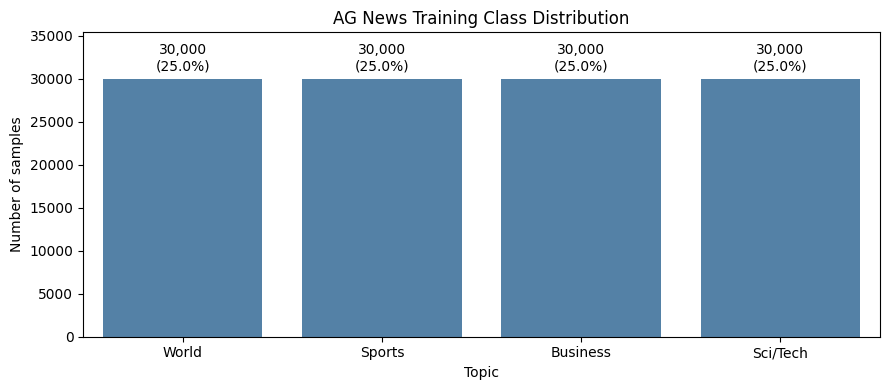

In [62]:
# 1. Summarize the number of samples in each split
class_counts = train_df["label"].value_counts().reindex(LABEL_MAP, fill_value=0)
topic_order = [LABEL_MAP[label] for label in class_counts.index]
class_distribution = pd.DataFrame({
    "Topic": topic_order,
    "Samples": class_counts.to_numpy(),
    "Percentage": 100 * class_counts.to_numpy() / len(train_df),
})
print(f"Number of training samples: {len(train_df):,}")
display(class_distribution.round({"Percentage": 2}))

# 2. Visualize the class distribution in the training set.
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=class_distribution, x="Topic", y="Samples", color="steelblue", ax=ax)
ax.set(title="AG News Training Class Distribution", xlabel="Topic", ylabel="Number of samples")
for bar, percentage in zip(ax.patches, class_distribution["Percentage"]):
    ax.annotate(
        f"{int(bar.get_height()):,}\n({percentage:.1f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", xytext=(0, 4), textcoords="offset points",
    )
ax.set_ylim(0, max(class_distribution["Samples"]) * 1.18)
plt.tight_layout()
plt.show()


## 1.3. Text-Length Analysis

Text length is measured in two ways:

- **Character count:** Includes letters, spaces, and punctuation.
- **Word count:** Counts whitespace-separated words, rather than transformer tokens.

Summary statistics and histograms describe the overall lengths; boxplots compare the four topics. The 95th percentile marks a length that 95% of records do not exceed. The three shortest and longest records are inspected for each measure, without removing or truncating them.


### 1.3.1 Character count

In [63]:
# Add analysis columns to a separate copy of the training data.
eda_df = train_df.copy()
eda_df["topic"] = eda_df["label"].map(LABEL_MAP)
eda_df["char_count"] = eda_df[TEXT_COLUMN].str.len()
eda_df["word_count"] = eda_df[TEXT_COLUMN].str.split().str.len()
length_labels = {"char_count": "Character count", "word_count": "Whitespace word count"}

print("Training text-length descriptive statistics:")
length_statistics = eda_df[list(length_labels)].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).T.rename(index=length_labels)
display(length_statistics.round(2))

print("Text-length statistics by topic:")
per_class_lengths = (
    eda_df.groupby("topic")[list(length_labels)]
    .agg(["mean", "median", "min", "max"])
    .reindex(topic_order)
    .rename(columns=length_labels, level=0)
    .rename_axis("Topic")
)
display(per_class_lengths.round(2))


Training text-length descriptive statistics:


,count,mean,std,min,25%,50%,75%,95%,99%,max
Character count,120000.0,236.48,66.51,100.0,196.0,232.0,266.0,343.0,464.0,1012.0
Whitespace word count,120000.0,37.85,10.09,8.0,32.0,37.0,43.0,53.0,70.0,177.0


Text-length statistics by topic:


Character count                   Whitespace word count             \
                    mean median  min   max                  mean median min   
Topic                                                                         
World             242.63  243.0  100   865                 38.88   39.0  11   
Sports            224.65  220.0  100   853                 37.77   37.0   8   
Business          241.41  236.0  100  1006                 37.54   37.0   8   
Sci/Tech          237.22  230.0  100  1012                 37.19   36.0   8   

               
          max  
Topic          
World     145  
Sports    151  
Business  134  
Sci/Tech  177

### 1.3.2 Word count

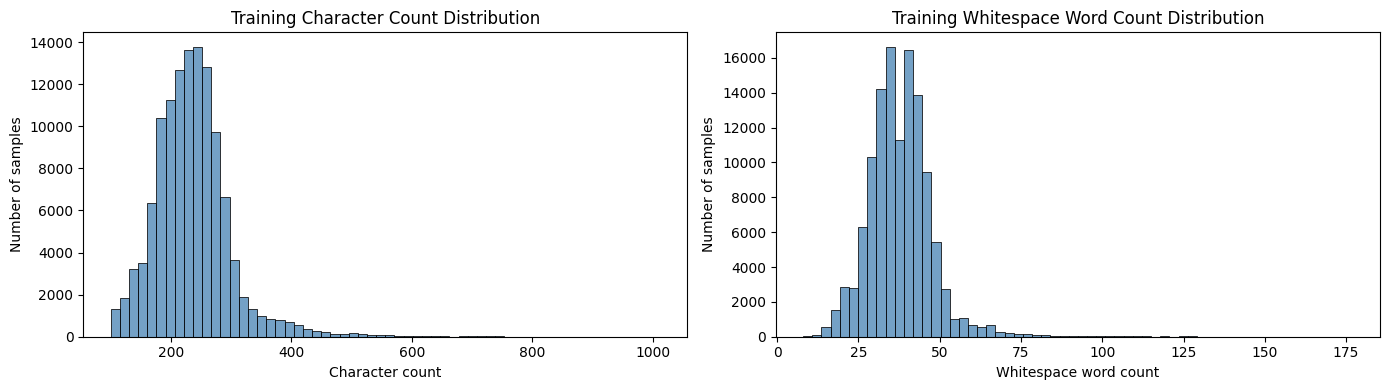

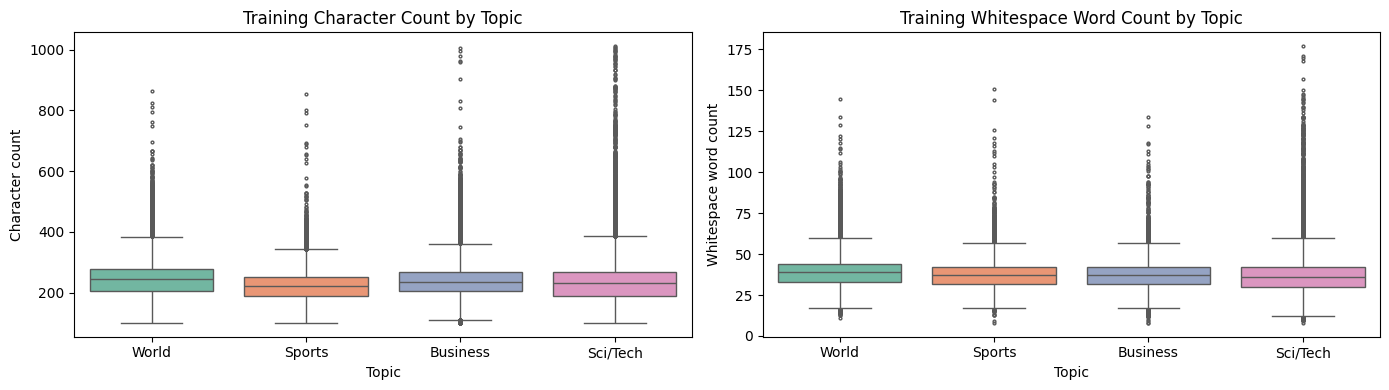

In [64]:
# Show the full training distributions.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (column, label) in zip(axes, length_labels.items()):
    sns.histplot(data=eda_df, x=column, bins=60, color="steelblue", ax=ax)
    ax.set(title=f"Training {label.title()} Distribution", xlabel=label, ylabel="Number of samples")
plt.tight_layout()
plt.show()

# Compare text lengths across the four topics.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (column, label) in zip(axes, length_labels.items()):
    sns.boxplot(
        data=eda_df, x="topic", y=column, order=topic_order,
        hue="topic", hue_order=topic_order, palette="Set2",
        legend=False, fliersize=2, ax=ax,
    )
    ax.set(title=f"Training {label.title()} by Topic", xlabel="Topic", ylabel=label)
plt.tight_layout()
plt.show()


In [65]:
# Inspect the shortest and longest records without excluding them.
preview_columns = ["topic", "char_count", "word_count", TEXT_COLUMN]
for column, label in length_labels.items():
    print(f"Shortest texts by {label}:")
    with pd.option_context("display.max_colwidth", 180):
        display(eda_df.nsmallest(3, column)[preview_columns])
    print(f"Longest texts by {label}:")
    with pd.option_context("display.max_colwidth", 180):
        display(eda_df.nlargest(3, column)[preview_columns])


Shortest texts by Character count:


,topic,char_count,word_count,text
55,Business,100,16,Hip Hop's Online Shop Celebrity fashion is booming. These webpreneurs are bringing it to main street
591,Sports,100,18,"US NBA players become the Nightmare Team after epic loss (AFP) AFP - Call them the ""Nightmare Team""."
921,Business,100,21,A Stereo with a Brain You can train Bose's new system to play songs you like. Is it worth the price?


Longest texts by Character count:


,topic,char_count,word_count,text
95659,Sci/Tech,1012,102,"Yahoo, SBC extend partnership, plan new services Yahoo and SBC Communications will collaborate to extend to cell phones and home entertainment devices some of the online servic..."
106486,Sci/Tech,1009,103,"Nokia earmarks millions to build new plant in India Nokia, the world's largest handset maker, is investing up to \$150 million over the next four years to establish a manufactu..."
105792,Sci/Tech,1007,101,IBM to market Sybase Linux database IBMand Sybasehave teamed to add support for Sybase's database software on IBM's eServer OpenPower Linux servers. The two companies said they...


Shortest texts by Whitespace word count:


,topic,char_count,word_count,text
26803,Business,159,8,"Stocks to Watch ORACLE CORP. &lt;A HREF=""http://www.investor.reuters.com/FullQuote.aspx?ticker=ORCL.O target=/stocks/quickinfo/fullquote""&gt;ORCL.O&lt;/A&gt;:"
88878,Business,156,8,"Stocks to Watch DELL INC. &lt;A HREF=""http://www.investor.reuters.com/FullQuote.aspx?ticker=DELL.O target=/stocks/quickinfo/fullquote""&gt;DELL.O&lt;/A&gt;:"
114582,Sci/Tech,105,8,The PeopleSoft vs. Oracle clash &lt;strong&gt;A &lt;cite&gt;Register&lt;/cite&gt; History&lt;/strong&gt;


Longest texts by Whitespace word count:


,topic,char_count,word_count,text
69024,Sci/Tech,967,177,"2004 US Senate Outlook With all the hoopla over Bush and Kerry, some of you may not have been paying close attention to the other races going on in this loaded US political sea..."
19776,Sci/Tech,1002,171,Making RSS Scale I've been meaning to write about this since I saw a one-page article on the subject of RSS clogging websites' bandwidth in NewScientist back in June. But i...
32433,Sci/Tech,992,170,"Kyoto is Dead - Long Live Pragmatism There's troubling news (FT subscription reqd, alternate copy here) coming from Japan, where the Kyoto protocol on Greenhouse Emissions ..."


Word-count outliers are identified below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`, where `IQR = Q3 - Q1`. The outlier count and five examples support inspection; flagged records are retained.

In [66]:
# Identify training text outliers by word count.
q1 = eda_df['word_count'].quantile(0.25)
q3 = eda_df['word_count'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

outliers = eda_df[
    (eda_df['word_count'] < lower_bound) | (eda_df['word_count'] > upper_bound)
]
print(f"Word-count outlier bounds: {lower_bound:g} to {upper_bound:g}")
print(f"Number of training text outliers: {outliers.shape[0]:,}")
display(outliers.head())

Word-count outlier bounds: 15.5 to 59.5
Number of training text outliers: 3,568


,text,label,topic,char_count,word_count
8,Safety Net (Forbes.com) Forbes.com - After ear...,2,Business,414,68
39,Microsoft Corp. 2.0: a kinder corporate cultur...,2,Business,416,67
40,Letters Target the abusers of legal weapons We...,2,Business,391,64
59,"Barrel of Monkeys, 2004 Edition: Notes on Phil...",2,Business,498,82
61,Not All Jobs Belong To The White Man: Asian Mi...,2,Business,504,73


## 1.4. Vocabulary and Word Frequencies

Words are counted after lowercasing, using alphabetic tokens that may contain internal apostrophes. Numbers and other punctuation are excluded from the counts.

- **Token occurrences:** Total number of words counted, including repetitions.
- **Unique word types:** Number of distinct words counted.

The charts compare frequent words overall and by topic. The filtered views remove scikit-learn's standard English stopwords and tokens shorter than two characters. The **All Tokens** view retains these tokens, and the original text remains unchanged.


### 1.4.1. Token occurrences

In [67]:
def tokenize_text(text):
    """Lowercase text and extract alphabetic words with internal apostrophes."""
    return re.findall(r"\b[a-z]+(?:'[a-z]+)?\b", text.lower())

def count_analysis_words(texts):
    """Count words across a collection of news texts."""
    counts = Counter()
    for text in texts.dropna():
        counts.update(tokenize_text(text))
    return counts

def filter_word_counts(counts):
    """Remove standard stopwords and one-character tokens from EDA counts."""
    return Counter({
        word: count for word, count in counts.items()
        if word not in ENGLISH_STOP_WORDS and len(word) >= 2
    })

def plot_word_frequencies(counts, title, ax, top_n=20):
    """Display the most frequent words as a horizontal bar chart."""
    frequencies = pd.DataFrame(counts.most_common(top_n), columns=["Word", "Count"])
    sns.barplot(data=frequencies, x="Count", y="Word", color="steelblue", ax=ax)
    ax.set(title=title, xlabel="Token occurrences", ylabel="Word")

# Count words by topic, then combine them for the overall vocabulary.
word_counts_by_topic = {
    topic: count_analysis_words(train_df.loc[train_df["label"].eq(label), TEXT_COLUMN])
    for label, topic in LABEL_MAP.items()
}
overall_word_counts = Counter()
for counts in word_counts_by_topic.values():
    overall_word_counts.update(counts)

lexical_summary = pd.DataFrame([
    {"Topic": topic, "Token occurrences": sum(counts.values()), "Unique word types": len(counts)}
    for topic, counts in word_counts_by_topic.items()
])
display(lexical_summary)
print(f"Distinct word types in all training text: {len(overall_word_counts):,}")


,Topic,Token occurrences,Unique word types
0,World,1162303,30108
1,Sports,1110735,31078
2,Business,1156362,27403
3,Sci/Tech,1134398,32877


Distinct word types in all training text: 64,365


### 1.4.2. Unique word types - Word Frequencies

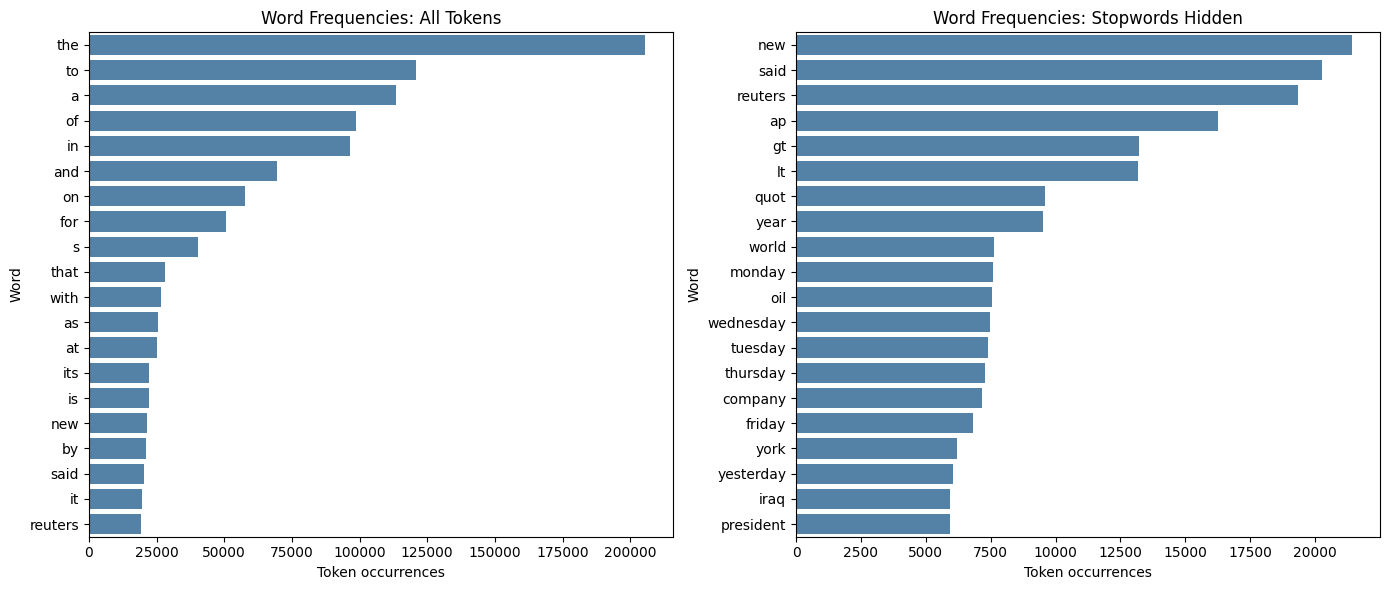

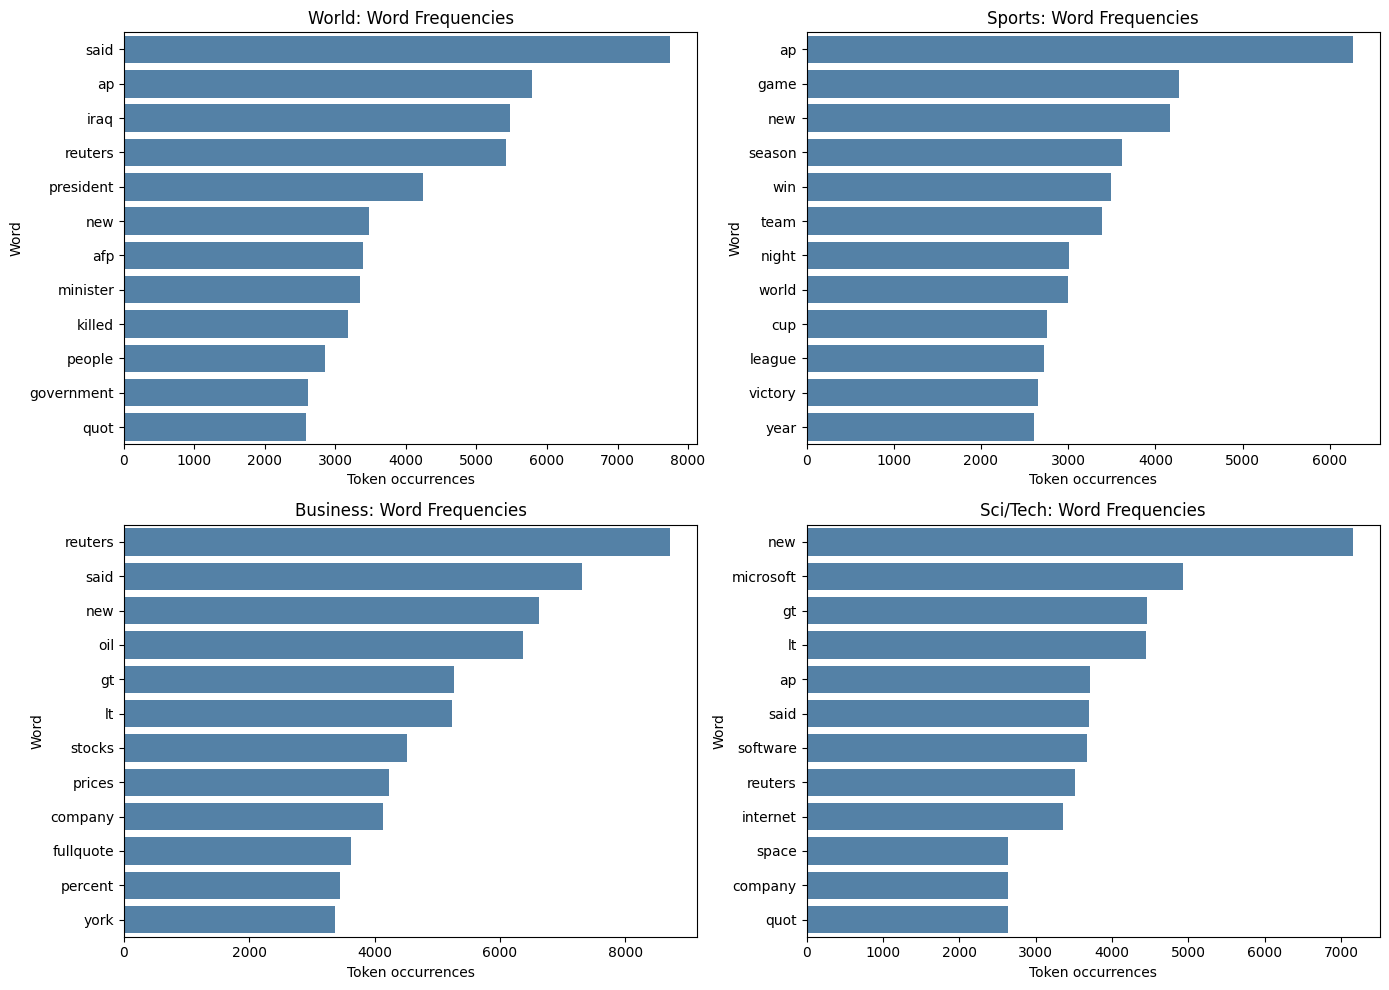

In [68]:
content_counts_by_topic = {
    topic: filter_word_counts(counts) for topic, counts in word_counts_by_topic.items()
}
overall_content_counts = filter_word_counts(overall_word_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_word_frequencies(overall_word_counts, "Word Frequencies: All Tokens", axes[0])
plot_word_frequencies(overall_content_counts, "Word Frequencies: Stopwords Hidden", axes[1])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, topic in zip(axes.flat, topic_order):
    plot_word_frequencies(content_counts_by_topic[topic], f"{topic}: Word Frequencies", ax, top_n=12)
plt.tight_layout()
plt.show()


####  **Text Preprocessing Trial**

The frequency analysis identified HTML fragments (`gt`, `lt`, `quot`), news-agency names (`reuters`, `ap`), and the common reporting verb `said`. The trial applies four steps:

1. Repair entities missing `&`, decode them with [`html.unescape()`](https://docs.python.org/3/library/html.html#html.unescape), and remove HTML tags while keeping their content.
2. Lowercase and tokenize the text using the same word-counting rule.
3. Remove standard English stopwords and the six custom stopwords above.
4. Keep words with **length >= 2**.

Processed text is stored separately in `text_processed`. The top-20 charts compare the existing stopword/length filter with the trial. Original texts and the test split remain unchanged.


In [69]:
CUSTOM_STOP_WORDS = {"reuters", "ap", "said", "gt", "lt", "quot"}
TEXT_STOP_WORDS = ENGLISH_STOP_WORDS | CUSTOM_STOP_WORDS

def clean_html_text(text):
    """Repair observed HTML entities and remove tags without removing their content."""
    text = re.sub(
        r"(?<!&)(#(?:\d+|[xX][0-9a-fA-F]+)|\b(?:lt|gt|quot|apos));",
        r"&\1;",
        text,
    )
    return re.sub(r"</?[A-Za-z][^<>]*>", " ", unescape(text))

def preprocess_eda_text(text):
    """Apply the fixed cleaning trial used for the EDA frequency comparison."""
    words = tokenize_text(clean_html_text(text))
    return " ".join(
        word for word in words if word not in TEXT_STOP_WORDS and len(word) >= 2
    )

processed_train_df = train_df.copy()
processed_train_df["text_processed"] = train_df[TEXT_COLUMN].map(preprocess_eda_text)

processed_counts_by_topic = {
    topic: count_analysis_words(
        processed_train_df.loc[processed_train_df["label"].eq(label), "text_processed"]
    )
    for label, topic in LABEL_MAP.items()
}
overall_processed_counts = Counter()
for counts in processed_counts_by_topic.values():
    overall_processed_counts.update(counts)


,Token,Before,After
0,ap,16274,0
1,gt,13231,0
2,lt,13182,0
3,quot,9596,0
4,reuters,19340,0
5,said,20267,0


Training records retained: 120,000
Empty processed texts: 0
Token occurrences before: 2,881,252
Token occurrences after: 2,755,222


,text,text_processed
40,"Letters Target the abusers of legal weapons We can all share the outrage, expressed by columnist Steve Bailey (''Summer Sizzler, quot; Aug. 11), at the kill...",letters target abusers legal weapons share outrage expressed columnist steve bailey summer sizzler aug killings city's poor neighborhoods there's need share...
41,Somewhere between gleam and gloom President Bush has been saying that the US economy has ''turned the corner. quot; Democratic presidential candidate Senato...,gleam gloom president bush saying economy turned corner democratic presidential candidate senator john kerry wake month's poor jobs report quipped like turn
161,Junk faxes to be legalized as quot;opt-out? quot; The Register ran a story on August 6th called 'Phone spam misery looms stateside.' It seems that there's ...,junk faxes legalized opt register ran story august called phone spam misery looms stateside there's legislative nastiness underway washington dc essentially...


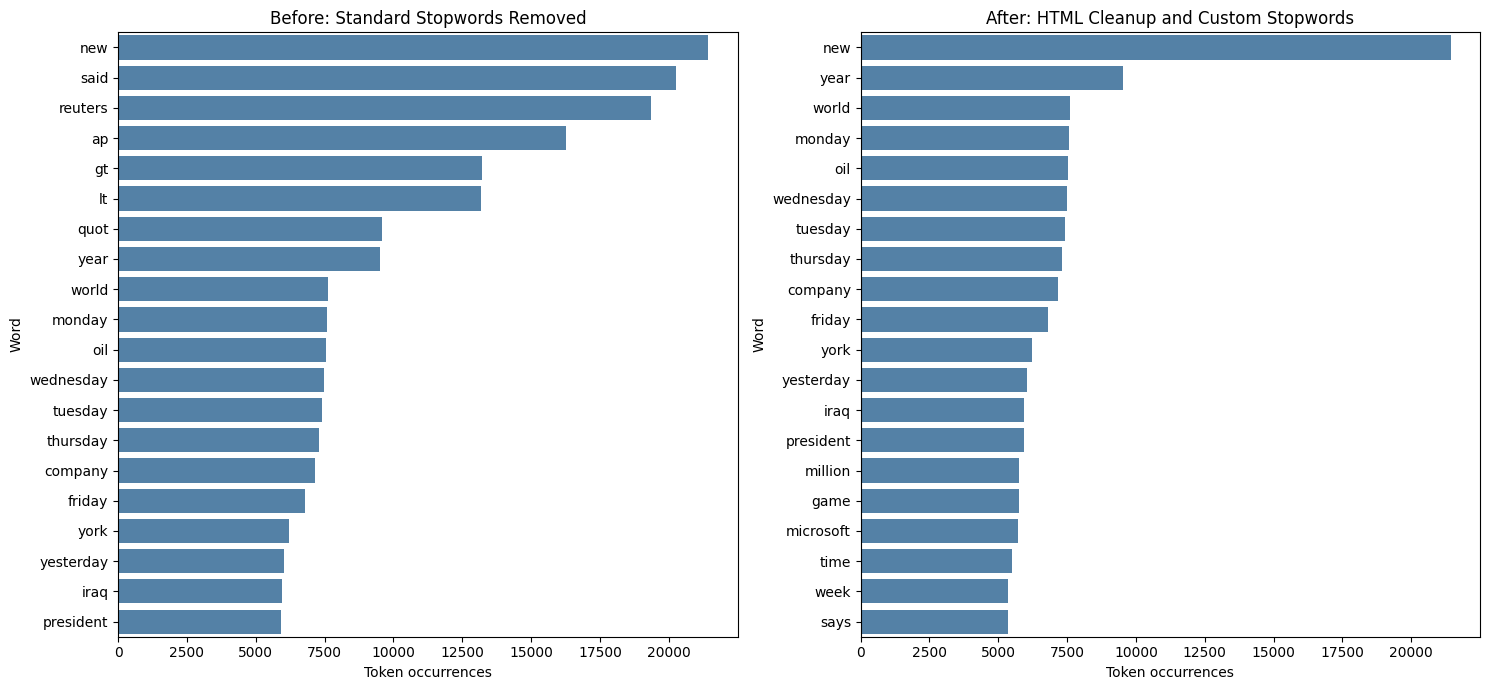

In [70]:
noise_comparison = pd.DataFrame([
    {"Token": word, "Before": overall_content_counts[word], "After": overall_processed_counts[word]}
    for word in sorted(CUSTOM_STOP_WORDS)
])
display(noise_comparison)
print(f"Training records retained: {len(processed_train_df):,}")
print(f"Empty processed texts: {processed_train_df['text_processed'].eq('').sum():,}")
print(f"Token occurrences before: {sum(overall_content_counts.values()):,}")
print(f"Token occurrences after: {sum(overall_processed_counts.values()):,}")

# Compare original and processed examples containing HTML fragments.
html_examples = train_df[TEXT_COLUMN].str.contains(r"&lt;|&gt;|quot;|#39;", na=False)
with pd.option_context("display.max_colwidth", 160):
    display(processed_train_df.loc[html_examples, [TEXT_COLUMN, "text_processed"]].head(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
plot_word_frequencies(overall_content_counts, "Before: Standard Stopwords Removed", axes[0])
plot_word_frequencies(overall_processed_counts, "After: HTML Cleanup and Custom Stopwords", axes[1])
plt.tight_layout()
plt.show()


**Trial result:** The six selected tokens decreased from **91,890 occurrences to 0**. All **120,000 training records** were retained, with **no empty processed texts**. This result shows that the rule removes the intended vocabulary items, but it does not show that their removal improves classification. The original traditional baseline therefore keeps stopword removal disabled. Section 5.5 evaluates the classification effect of custom and standard stopword removal on the validation set.


## 1.5. WordClouds

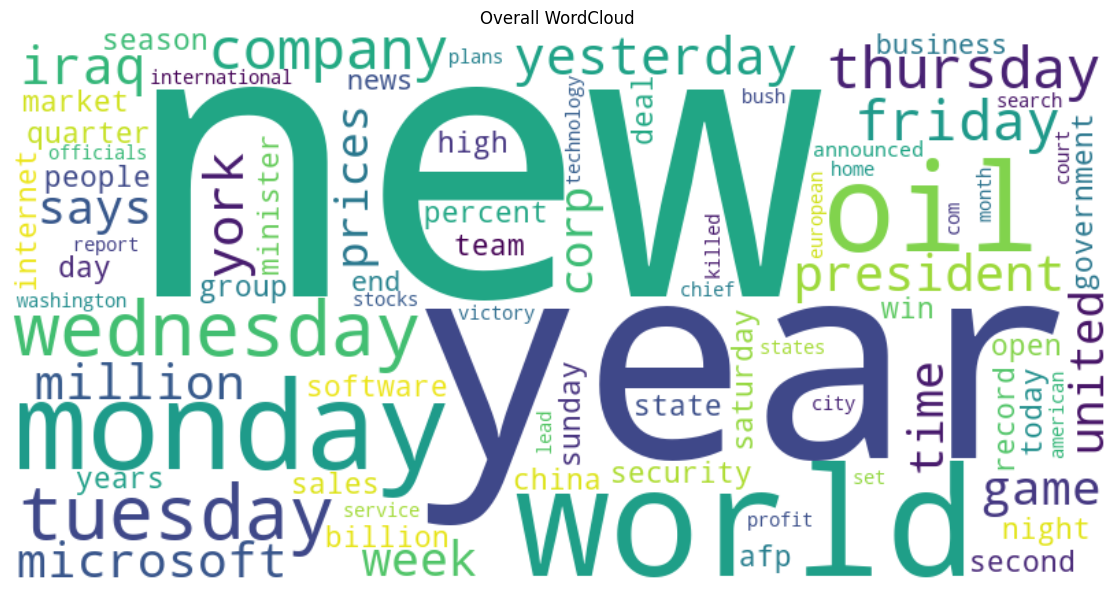

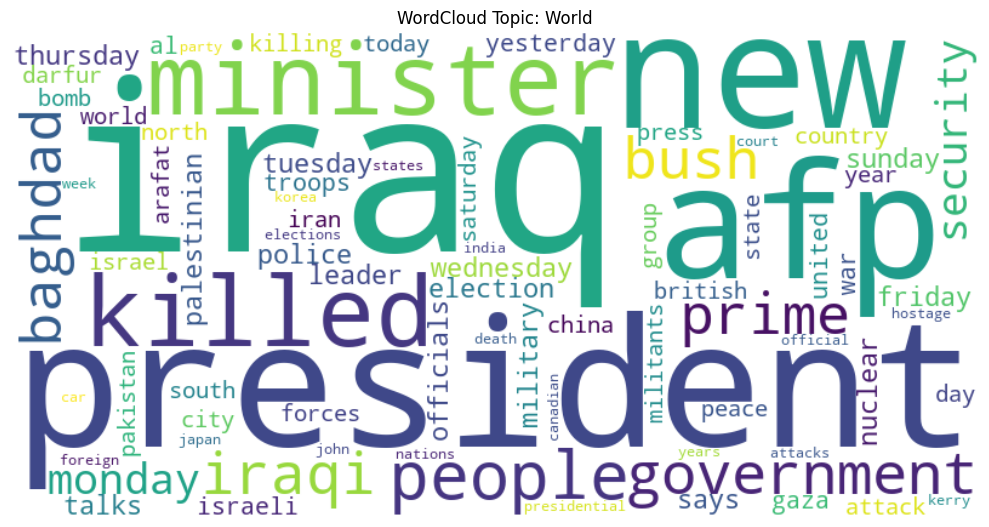

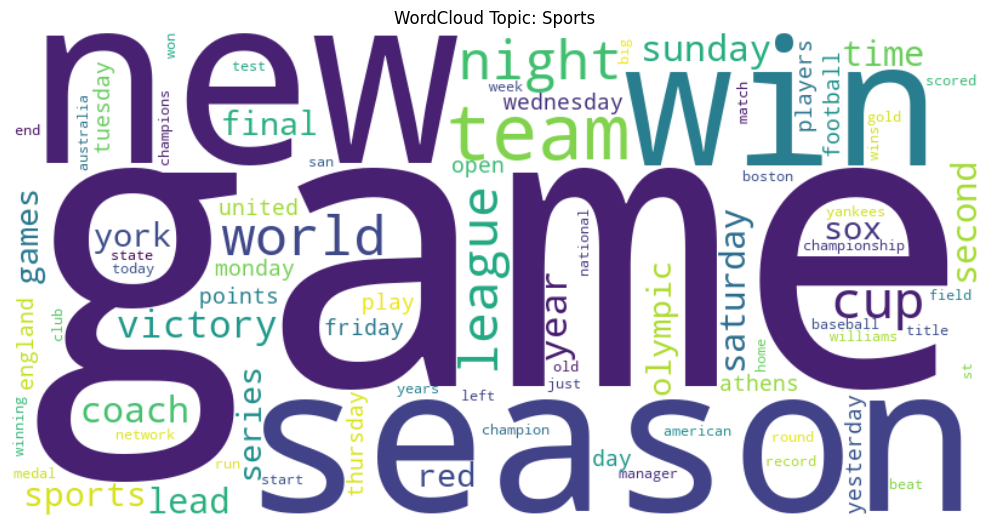

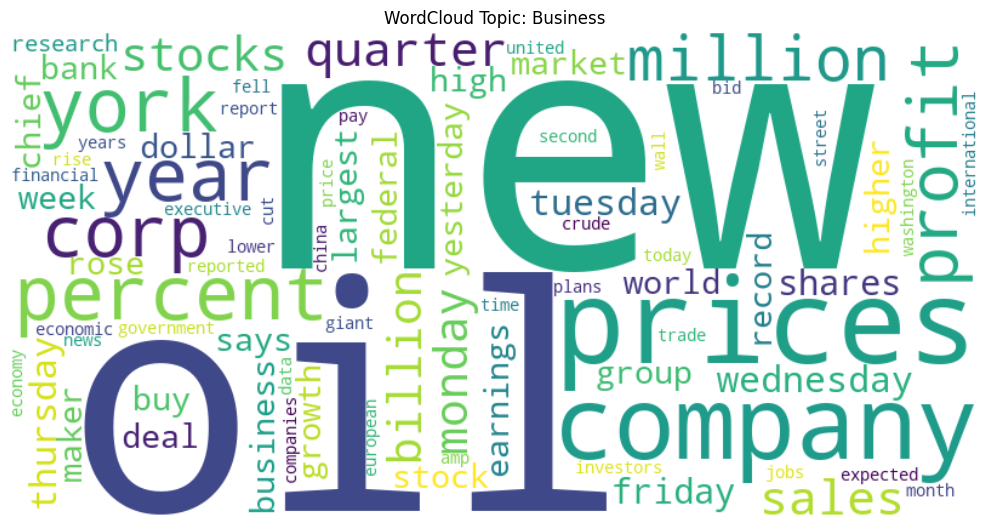

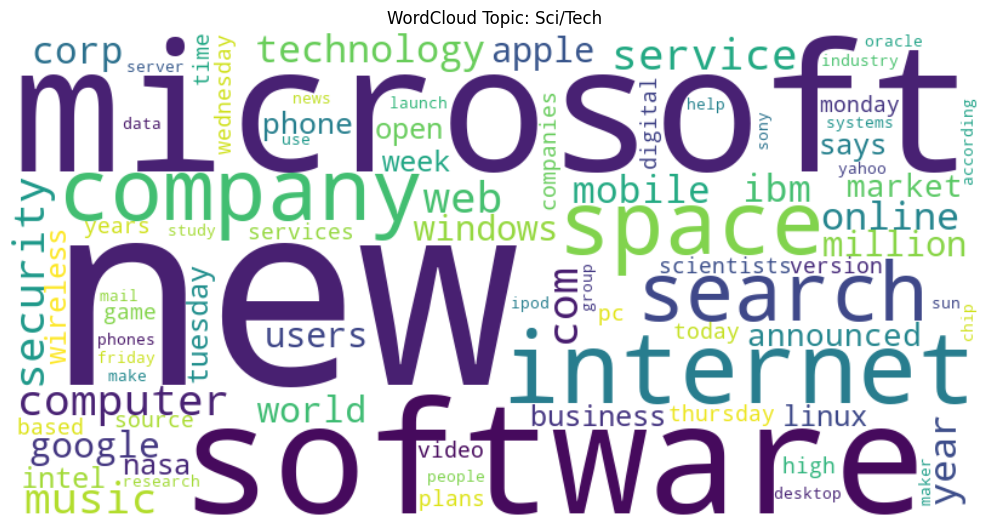

In [71]:
def plot_wordcloud(counts, title, ax):
    """Visualize word frequencies with a reproducible WordCloud."""
    cloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=80,
        random_state=SEED,
    ).generate_from_frequencies(counts)
    ax.imshow(cloud, interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(12, 6))
plot_wordcloud(overall_processed_counts, "Overall WordCloud", ax)
plt.tight_layout()
plt.show()

for topic in topic_order:
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_wordcloud(processed_counts_by_topic[topic], f"WordCloud Topic: {topic}", ax)
    plt.tight_layout()
    plt.show()


## 1.6. Duplicate and Suspicious Training Texts

### 1.6.1. Exact Text Matches

Repeated original texts are grouped by their text value. Groups with one label are separated from groups with different labels. The summary reports the number of groups and all records involved.


In [72]:
raw_duplicate_mask = train_df[TEXT_COLUMN].notna() & train_df.duplicated(TEXT_COLUMN, keep=False)
raw_duplicate_records = train_df.loc[raw_duplicate_mask]

exact_duplicate_groups = (
    raw_duplicate_records.groupby(TEXT_COLUMN)
    .agg(
        Samples=("label", "size"),
        Distinct_labels=("label", "nunique"),
        Topics=("label", lambda labels: ", ".join(LABEL_MAP[label] for label in sorted(set(labels)))),
    )
    .reset_index()
)
duplicate_groups = {
    "Exact text, same label": exact_duplicate_groups.loc[exact_duplicate_groups["Distinct_labels"].eq(1)],
    "Exact text, different labels": exact_duplicate_groups.loc[exact_duplicate_groups["Distinct_labels"].gt(1)],
}
display(pd.DataFrame([
    {"Type": name, "Text groups": len(groups), "Samples involved": groups["Samples"].sum()}
    for name, groups in duplicate_groups.items()
]))

for name, groups in duplicate_groups.items():
    print(f"{name}:")
    if groups.empty:
        print("None detected.")
    else:
        with pd.option_context("display.max_colwidth", 180):
            display(groups.nlargest(10, "Samples"))


,Type,Text groups,Samples involved
0,"Exact text, same label",0,0
1,"Exact text, different labels",0,0


Exact text, same label:
None detected.
Exact text, different labels:
None detected.


### 1.6.2. Comparison-Key Matches

Texts are cleaned by ignoring case, punctuation, and extra spaces to find near-duplicates. If matching texts have different labels, they are flagged for review. A match suggests a possible conflict, but it does not automatically prove a label is incorrect.


In [73]:
def make_comparison_key(text):
    """Normalize formatting for duplicate inspection."""
    normalized = unicodedata.normalize("NFKC", text).casefold()
    return re.sub(r"[\W_]+", " ", normalized).strip()

comparison_df = eda_df[[TEXT_COLUMN, "label", "topic"]].copy()
comparison_df["comparison_key"] = comparison_df[TEXT_COLUMN].map(make_comparison_key)

# Group only repeated, non-empty keys.
repeated_key_mask = (
    comparison_df["comparison_key"].ne("")
    & comparison_df.duplicated("comparison_key", keep=False)
)
repeated_key_records = comparison_df.loc[repeated_key_mask]
key_groups = repeated_key_records.groupby("comparison_key").agg(
    Samples=("label", "size"), Distinct_labels=("label", "nunique")
)
conflicting_key_groups = key_groups.loc[key_groups["Distinct_labels"].gt(1)]
print(f"Repeated comparison-key groups: {len(key_groups):,}")
print(f"Comparison-key groups with different labels: {len(conflicting_key_groups):,}")

if conflicting_key_groups.empty:
    print("No cross-label comparison-key matches detected.")
else:
    # Show two different labels from each of the three largest candidate groups.
    preview_keys = conflicting_key_groups.nlargest(3, "Samples").index
    for number, key in enumerate(preview_keys, start=1):
        print(f"Candidate group {number}:")
        preview = repeated_key_records.loc[
            repeated_key_records["comparison_key"].eq(key)
        ].drop_duplicates("label").head(2)
        with pd.option_context("display.max_colwidth", 180):
            display(preview[["topic", TEXT_COLUMN]])


Repeated comparison-key groups: 218
Comparison-key groups with different labels: 28
Candidate group 1:


,topic,text
4671,Business,"Amazon to purchase Chinese on-line retailer Amazon.com Inc. has agreed to buy Joyo.com, China #39;s largest on-line retailer of books, music and videos, for \$75-million (US) t..."
5653,Sci/Tech,"Amazon to purchase Chinese on-line retailer Amazon.com Inc. has agreed to buy Joyo.com, China #39;s largest on-line retailer of books, music and videos, for \$75-million (US) t..."


Candidate group 2:


,topic,text
76100,Sci/Tech,AMD Introduces Low-Cost Net Access Device in India (Reuters) Reuters - U.S. chip maker Advanced Micro Devices\Inc. has introduced a low-cost Internet access device\that could ...
76153,World,AMD introduces low-cost Net access device in India (Reuters) Reuters - U.S. chip maker Advanced Micro Devices Inc. has introduced a low-cost Internet access device that could c...


Candidate group 3:


,topic,text
11443,Sci/Tech,Comcast Subpoenas Elected Leaders In Montgomery Who Favored Union Two Montgomery County Council members who supported a campaign by employees of Comcast Cable Communications to...
11464,Business,Comcast Subpoenas Elected Leaders In Montgomery Who Favored Union Two Montgomery County Council members who supported a campaign by employees of Comcast Cable Communications t...


# **2. Text Preprocessing**
---
Two text versions are prepared for traditional classifiers and deep learning models. Explicit parameters allow preprocessing choices to be changed while retaining the original `text` field.

In [74]:
from functools import cache
from nltk.stem import WordNetLemmatizer

@cache
def get_lemmatizer():
    '''Download and load WordNet once, only when lemmatization is requested.'''
    nltk_dir = Path("data") / "nltk_data"
    nltk.data.path.insert(0, str(nltk_dir.resolve()))
    nltk.download("wordnet", download_dir=str(nltk_dir), quiet=True, raise_on_error=True)
    return WordNetLemmatizer()

def preprocess_text(
    text,
    lowercase=False,
    normalize_whitespace=True,
    clean_html=True,
    remove_punctuation=False,
    remove_stopwords=False,
    remove_standard_stopwords=False,
    remove_custom_stopwords=False,
    custom_stopwords=(),
    lemmatize=False,
    min_token_length=1,
):
    '''Prepare text using explicit options, without learning from the dataset.'''
    if clean_html:
        text = clean_html_text(text)
    if lowercase:
        text = text.lower()
    if remove_punctuation:
        text = re.sub(r"[^\w\s]|_", " ", text)

    # The combined flag preserves the original function behavior when enabled.
    use_standard_stopwords = remove_stopwords or remove_standard_stopwords
    use_custom_stopwords = remove_stopwords or remove_custom_stopwords
    use_word_options = (
        use_standard_stopwords
        or use_custom_stopwords
        or lemmatize
        or min_token_length > 1
    )

    if use_word_options:
        active_stopwords = set()
        if use_standard_stopwords:
            active_stopwords.update(ENGLISH_STOP_WORDS)
        if use_custom_stopwords:
            active_stopwords.update(word.casefold() for word in custom_stopwords)
        lemmatizer = get_lemmatizer() if lemmatize else None

        def process_word(match):
            word = match.group(0)
            if word.casefold() in active_stopwords:
                return ""
            if lemmatize:
                word = lemmatizer.lemmatize(word, pos="n")
            return word if len(word) >= min_token_length else ""

        text = re.sub(r"\b\w+(?:['’]\w+)*\b", process_word, text)

    if normalize_whitespace:
        text = re.sub(r"\s+", " ", text).strip()
    return text


## **Preprocessing Configurations**

### Configuration A — Traditional ML Cleaning

The baseline lowercases text, removes punctuation, normalizes whitespace, and keeps tokens with length >= 2. Stopword removal and lemmatization remain disabled, preserving the configuration used for the original traditional experiments.

### Configuration B — Deep Learning / Transformer Cleaning

This configuration repairs HTML artifacts and normalizes whitespace. It preserves letter case, punctuation, numbers, short words, and contextual words for the model tokenizer.

The preprocessing ablation in Section 5.5 separates standard and custom stopword removal. The original `remove_stopwords` option remains backward compatible: if enabled, it removes both sets. Optional WordNet lemmatization uses noun forms without POS tagging and downloads its corpus only when requested.


In [75]:
CONFIG_A = {
    "lowercase": True,
    "normalize_whitespace": True,
    "clean_html": True,
    "remove_punctuation": True,
    "remove_stopwords": False,
    "remove_standard_stopwords": False,
    "remove_custom_stopwords": False,
    "custom_stopwords": tuple(sorted(CUSTOM_STOP_WORDS)),
    "lemmatize": False,
    "min_token_length": 2,
}

CONFIG_B = {
    "lowercase": False,
    "normalize_whitespace": True,
    "clean_html": True,
    "remove_punctuation": False,
    "remove_stopwords": False,
    "remove_standard_stopwords": False,
    "remove_custom_stopwords": False,
    "custom_stopwords": (),
    "lemmatize": False,
    "min_token_length": 1,
}

PREPROCESSING_ABLATION_CONFIGS = {
    "P0": CONFIG_A.copy(),
    "P1": {
        **CONFIG_A,
        "remove_custom_stopwords": True,
    },
    "P2": {
        **CONFIG_A,
        "remove_standard_stopwords": True,
        "remove_custom_stopwords": True,
    },
}
PREPROCESSING_ABLATION_DESCRIPTIONS = {
    "P0": "Existing baseline: no stopword removal",
    "P1": "Remove the six custom stopwords only",
    "P2": "Remove standard English and custom stopwords",
}


### Preprocessing Unit Checks

The checks below use a short sentence containing one-character text, custom stopwords, and standard English stopwords. They verify that the token callback is applied and that P0, P1, and P2 implement distinct rules.


In [76]:
PREPROCESSING_TEST_TEXT = "AP said the x market is up."
expected_preprocessing_outputs = {
    "P0": "ap said the market is up",
    "P1": "the market is up",
    "P2": "market",
}
actual_preprocessing_outputs = {
    config_id: preprocess_text(
        PREPROCESSING_TEST_TEXT,
        **preprocessing_config,
    )
    for config_id, preprocessing_config in PREPROCESSING_ABLATION_CONFIGS.items()
}

assert actual_preprocessing_outputs == expected_preprocessing_outputs
assert len(set(actual_preprocessing_outputs.values())) == 3
display(pd.DataFrame({
    "Configuration": actual_preprocessing_outputs.keys(),
    "Processed text": actual_preprocessing_outputs.values(),
}))
print("P0, P1, and P2 preprocessing unit checks passed.")


,Configuration,Processed text
0,P0,ap said the market is up
1,P1,the market is up
2,P2,market


P0, P1, and P2 preprocessing unit checks passed.


# **3. Training, Validation, and Test Preparation**
---
The official AG News test split remains the final held-out evaluation set. The training protocol is modified to address content-equivalent records found across the official splits: normalized comparison keys are used to exclude **40 official training records** whose keys also occur in the test inputs. This procedure uses test text, although it does not use test labels or test performance. It therefore differs from an experiment trained on all 120,000 official training records.

The remaining official training records are divided into training and validation subsets with grouped, stratified splitting, using **VALIDATION_RATIO = 0.10** and **SEED = 42**. Each prepared record retains its original text and label together with the two fixed preprocessing versions.


In [77]:
VALIDATION_RATIO = 0.10

def make_split_group(text):
    """Compare news content while ignoring HTML, formatting, and short fragments."""
    words = make_comparison_key(clean_html_text(text)).split()
    return " ".join(word for word in words if len(word) >= 2)

def prepare_split_texts(frame, source):
    """Keep original text and add fixed cleaning versions and source identifiers."""
    prepared = frame.copy()
    prepared["source_id"] = source + ":" + frame.index.astype(str)
    prepared["split_group"] = frame[TEXT_COLUMN].map(make_split_group)
    prepared["text_traditional"] = frame[TEXT_COLUMN].map(
        lambda text: preprocess_text(text, **CONFIG_A)
    )
    prepared["text_minimal"] = frame[TEXT_COLUMN].map(
        lambda text: preprocess_text(text, **CONFIG_B)
    )
    return prepared

training_pool = prepare_split_texts(train_df, "official_train")
test_split = prepare_split_texts(test_df, "official_test")


## 3.1. Split Construction

To prevent data leakage, text inputs are normalized into comparison keys by stripping HTML artifacts, punctuation, whitespace, and single-character fragments, while ignoring letter case. Any training records matching test set keys are removed to ensure the final evaluation genuinely tests generalization. Because test inputs help determine which training samples are retained, this setup is reported as a modified AG News protocol rather than the untouched official split.

For the remaining training data, identical records are clustered by comparison key:

- Stratification: Each group is assigned its majority label (with ties resolved by selecting the lowest numeric label) solely to maintain balanced class proportions across splits.

- Group-level Splitting: Each group is assigned as a single unit to either the training or validation set, ensuring content-equivalent records never span across both sets.

Individual sample labels remain unchanged, and no test labels or test evaluation metrics are used during splitting or model selection.


In [78]:
# 1. Exclude official training records with comparison keys found in test inputs.
test_groups = set(test_split["split_group"])
test_overlap_mask = training_pool["split_group"].isin(test_groups)
training_exclusions = training_pool.loc[test_overlap_mask].copy()
training_pool = training_pool.loc[~test_overlap_mask].copy()
print(f"Official training records excluded for test overlap: {len(training_exclusions):,}")

# 2. Stratify comparison groups by their majority training label.
group_labels = training_pool.groupby("split_group")["label"].agg(
    lambda labels: labels.mode().iat[0]
)
train_groups, validation_groups = train_test_split(
    group_labels.index,
    test_size=VALIDATION_RATIO,
    stratify=group_labels,
    random_state=SEED,
)

# 3. Create the final splits without changing row order within each subset.
train_split = training_pool.loc[training_pool["split_group"].isin(train_groups)].copy()
validation_split = training_pool.loc[
    training_pool["split_group"].isin(validation_groups)
].copy()
prepared_splits = {"Train": train_split, "Validation": validation_split, "Test": test_split}

# 4. Guard the established experimental protocol against silent changes.
EXPECTED_PROTOCOL_COUNTS = {
    "Excluded official training": 40,
    "Retained training pool": 119_960,
    "Train": 107_973,
    "Validation": 11_987,
    "Test": 7_600,
}
actual_protocol_counts = {
    "Excluded official training": len(training_exclusions),
    "Retained training pool": len(training_pool),
    "Train": len(train_split),
    "Validation": len(validation_split),
    "Test": len(test_split),
}
assert actual_protocol_counts == EXPECTED_PROTOCOL_COUNTS, (
    f"Split membership changed: {actual_protocol_counts}"
)


Official training records excluded for test overlap: 40


## 3.2. Sample Counts and Class Distribution

The tables report the actual sample count and class percentages after the 40-record exclusion. Assertions verify the established split sizes, valid targets, unique source identifiers, complete allocation of retained training records, and preservation of the official test text and labels.


In [79]:
# 1. Summarize the number of samples in each split.
split_summary = pd.DataFrame([
    {"Split": name, "Samples": len(frame)}
    for name, frame in prepared_splits.items()
])
display(split_summary)
print(f"Validation share of retained training records: {len(validation_split) / len(training_pool):.2%}")

# 2. Summarize the distribution of classes in each split.
class_rows = []
for name, frame in prepared_splits.items():
    counts = frame["label"].value_counts().reindex(LABEL_MAP, fill_value=0)
    for label, count in counts.items():
        class_rows.append({
            "Split": name,
            "Topic": LABEL_MAP[label],
            "Samples": count,
            "Percentage": 100 * count / len(frame),
        })
display(pd.DataFrame(class_rows).round({"Percentage": 2}))

# 3. Verify labels, allocation, identifiers, and the unchanged official test split.
valid_targets = set(LABEL_MAP)
assert all(set(frame["label"]).issubset(valid_targets) for frame in prepared_splits.values())
assert all(frame["source_id"].is_unique for frame in prepared_splits.values())
assert set(train_split["source_id"]) | set(validation_split["source_id"]) == set(training_pool["source_id"])
assert set(train_split["source_id"]).isdisjoint(validation_split["source_id"])
assert test_split[TEXT_COLUMN].reset_index(drop=True).equals(
    test_df[TEXT_COLUMN].reset_index(drop=True)
)
assert test_split["label"].reset_index(drop=True).equals(
    test_df["label"].reset_index(drop=True)
)
print("Split size, target, allocation, and official test preservation checks passed.")


,Split,Samples
0,Train,107973
1,Validation,11987
2,Test,7600


Validation share of retained training records: 9.99%


,Split,Topic,Samples,Percentage
0,Train,World,27000,25.01
1,Train,Sports,26999,25.01
2,Train,Business,26986,24.99
3,Train,Sci/Tech,26988,25.00
4,Validation,World,2998,25.01
5,Validation,Sports,2996,24.99
6,Validation,Business,3001,25.04
7,Validation,Sci/Tech,2992,24.96
8,Test,World,1900,25.00
9,Test,Sports,1900,25.00


Split size, target, allocation, and official test preservation checks passed.


## 3.3. Split Overlap Checks

Pairwise checks compare source identifiers, original texts, both processed text versions, and comparison groups. Zero counts indicate that none of these checked forms are shared across the prepared splits.


In [80]:
overlap_columns = {
    "Source IDs": "source_id",
    "Original text": TEXT_COLUMN,
    "Traditional text": "text_traditional",
    "Minimal text": "text_minimal",
    "Comparison groups": "split_group",
}
overlap_rows = []
for left, right in (("Train", "Validation"), ("Train", "Test"), ("Validation", "Test")):
    row = {"Split pair": f"{left} / {right}"}
    for name, column in overlap_columns.items():
        shared = set(prepared_splits[left][column]) & set(prepared_splits[right][column])
        row[name] = len(shared)
    overlap_rows.append(row)

overlap_summary = pd.DataFrame(overlap_rows)
display(overlap_summary)
assert overlap_summary.drop(columns="Split pair").eq(0).all().all(), (
    "Cross-split overlap detected; review comparison groups and cleaning configurations."
)
print("All split overlap checks passed.")


,Split pair,Source IDs,Original text,Traditional text,Minimal text,Comparison groups
0,Train / Validation,0,0,0,0,0
1,Train / Test,0,0,0,0,0
2,Validation / Test,0,0,0,0,0


All split overlap checks passed.


# **4. Traditional Text Feature Extraction**
---
This section converts the traditionally processed news text into sparse numerical features for conventional classifiers. Three focused configurations compare raw unigram counts, unigram TF-IDF weights, and TF-IDF with unigrams and bigrams. The configuration set is intentionally small so that later model comparisons remain interpretable and practical in Google Colab.

The data leakage rule is enforced throughout: each vectorizer learns its vocabulary and document-frequency statistics from `train_split` only. The fitted vectorizer then transforms `validation_split` and the held-out `test_split`.


## 4.1. Feature Configurations

[CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) provides the Bag-of-Words baseline. [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) adjusts term counts using inverse document frequency.

The unigram configurations share the same 50,000-feature limit for a controlled comparison. The unigram-plus-bigram configuration allows up to 100,000 features to represent short phrases while placing a clear limit on memory use. Terms occurring in only one training document or in more than 95% of training documents are excluded. Sublinear term frequency is used for TF-IDF to reduce the effect of repeated terms.


In [81]:
FEATURE_CONFIGS = {
    "bow_unigram": {
        "name": "Bag-of-Words unigram",
        "method": "bow",
        "max_features": 50_000,
        "min_df": 2,
        "max_df": 0.95,
        "ngram_range": (1, 1),
        "sublinear_tf": False,
    },
    "tfidf_unigram": {
        "name": "TF-IDF unigram",
        "method": "tfidf",
        "max_features": 50_000,
        "min_df": 2,
        "max_df": 0.95,
        "ngram_range": (1, 1),
        "sublinear_tf": True,
    },
    "tfidf_unigram_bigram": {
        "name": "TF-IDF unigram + bigram",
        "method": "tfidf",
        "max_features": 100_000,
        "min_df": 2,
        "max_df": 0.95,
        "ngram_range": (1, 2),
        "sublinear_tf": True,
    },
}

feature_config_table = pd.DataFrame([
    {
        "Configuration": key,
        "Representation": config["name"],
        "Max features": config["max_features"],
        "Min df": config["min_df"],
        "Max df": config["max_df"],
        "N-gram range": str(config["ngram_range"]),
        "Sublinear TF": config["sublinear_tf"],
    }
    for key, config in FEATURE_CONFIGS.items()
])
display(feature_config_table)


,Configuration,Representation,Max features,Min df,Max df,N-gram range,Sublinear TF
0,bow_unigram,Bag-of-Words unigram,50000,2,0.95,"(1, 1)",False
1,tfidf_unigram,TF-IDF unigram,50000,2,0.95,"(1, 1)",True
2,tfidf_unigram_bigram,TF-IDF unigram + bigram,100000,2,0.95,"(1, 2)",True


## 4.2. Sparse Feature Extraction

The reusable functions below create a vectorizer from one configuration and apply it consistently to all three splits. `fit_transform()` is called only on training text. Validation and test text use `transform()`, so neither split can influence the vocabulary or TF-IDF weights.

All outputs remain sparse. The summary reports matrix dimensions, vocabulary size, nonzero values, density, and extraction time to support the later choice of representations.


In [82]:
from scipy import sparse

def build_vectorizer(config):
    """Create one traditional text vectorizer from an explicit configuration."""
    common_params = {
        "max_features": config["max_features"],
        "min_df": config["min_df"],
        "max_df": config["max_df"],
        "ngram_range": config["ngram_range"],
        "lowercase": False,
    }
    if config["method"] == "bow":
        return CountVectorizer(dtype=np.int32, **common_params)
    if config["method"] == "tfidf":
        return TfidfVectorizer(
            sublinear_tf=config["sublinear_tf"],
            dtype=np.float32,
            **common_params,
        )
    raise ValueError(f"Unsupported feature method: {config['method']}")

def extract_sparse_features(config, train_text, validation_text, test_text):
    """Fit on training text and transform the validation and test text."""
    vectorizer = build_vectorizer(config)
    X_train = vectorizer.fit_transform(train_text)
    X_validation = vectorizer.transform(validation_text)
    X_test = vectorizer.transform(test_text)

    matrices = {
        "train": X_train,
        "validation": X_validation,
        "test": X_test,
    }
    assert all(sparse.issparse(matrix) for matrix in matrices.values())
    assert all(matrix.shape[1] == len(vectorizer.vocabulary_) for matrix in matrices.values())
    return vectorizer, matrices


In [83]:
TEXT_FEATURE_COLUMN = "text_traditional"
feature_sets = {}
feature_rows = []

for key, config in FEATURE_CONFIGS.items():
    start_time = perf_counter()
    vectorizer, matrices = extract_sparse_features(
        config,
        train_split[TEXT_FEATURE_COLUMN],
        validation_split[TEXT_FEATURE_COLUMN],
        test_split[TEXT_FEATURE_COLUMN],
    )
    elapsed_time = perf_counter() - start_time
    feature_sets[key] = {
        "vectorizer": vectorizer,
        "matrices": matrices,
    }

    X_train = matrices["train"]
    feature_rows.append({
        "Configuration": key,
        "Vocabulary size": len(vectorizer.vocabulary_),
        "Train shape": f"{X_train.shape[0]:,} x {X_train.shape[1]:,}",
        "Validation shape": (
            f"{matrices['validation'].shape[0]:,} x {matrices['validation'].shape[1]:,}"
        ),
        "Test shape": f"{matrices['test'].shape[0]:,} x {matrices['test'].shape[1]:,}",
        "Train nonzero values": X_train.nnz,
        "Train density (%)": 100 * X_train.nnz / (X_train.shape[0] * X_train.shape[1]),
        "Extraction time (s)": elapsed_time,
    })

feature_summary = pd.DataFrame(feature_rows)
display(feature_summary.round({
    "Train density (%)": 4,
    "Extraction time (s)": 2,
}))


,Configuration,Vocabulary size,Train shape,Validation shape,Test shape,Train nonzero values,Train density (%),Extraction time (s)
0,bow_unigram,40234,"107,973 x 40,234","11,987 x 40,234","7,600 x 40,234",3278198,0.0755,2.34
1,tfidf_unigram,40234,"107,973 x 40,234","11,987 x 40,234","7,600 x 40,234",3278198,0.0755,2.51
2,tfidf_unigram_bigram,100000,"107,973 x 100,000","11,987 x 100,000","7,600 x 100,000",5341406,0.0495,8.02


## 4.3. Saved Feature Files

The three selected representations are saved under `features/traditional/` for later model training and assignment packaging. [SciPy's `save_npz()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.save_npz.html) stores each sparse matrix in compressed `.npz` format without creating a dense copy. Target arrays are shared by the configurations and saved once as `.npy` files. The configuration and dimensionality tables are written to `results/tables/`.


In [84]:
TRADITIONAL_FEATURE_DIR = FEATURE_DIR / "traditional"
TRADITIONAL_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

def save_feature_matrices(configuration, matrices):
    """Save one configuration's sparse matrices and return their file details."""
    file_rows = []
    for split_name, matrix in matrices.items():
        path = TRADITIONAL_FEATURE_DIR / f"{configuration}_{split_name}.npz"
        sparse.save_npz(path, matrix, compressed=True)
        file_rows.append({
            "Configuration": configuration,
            "Split": split_name.title(),
            "File": path.as_posix(),
            "Size (MB)": path.stat().st_size / (1024 ** 2),
        })
    return file_rows

saved_file_rows = []
for configuration, feature_set in feature_sets.items():
    saved_file_rows.extend(
        save_feature_matrices(configuration, feature_set["matrices"])
    )

targets = {
    "train": train_split["label"].to_numpy(dtype=np.int64),
    "validation": validation_split["label"].to_numpy(dtype=np.int64),
    "test": test_split["label"].to_numpy(dtype=np.int64),
}
for split_name, labels in targets.items():
    np.save(TRADITIONAL_FEATURE_DIR / f"{split_name}_labels.npy", labels)

feature_config_table.to_csv(
    TABLE_DIR / "traditional_feature_configurations.csv", index=False
)
feature_summary.to_csv(
    TABLE_DIR / "traditional_feature_summary.csv", index=False
)

saved_feature_files = pd.DataFrame(saved_file_rows)
display(saved_feature_files.round({"Size (MB)": 2}))
print(f"Saved {len(saved_feature_files)} sparse feature matrices.")


,Configuration,Split,File,Size (MB)
0,bow_unigram,Train,features/traditional/bow_unigram_train.npz,6.35
1,bow_unigram,Validation,features/traditional/bow_unigram_validation.npz,0.73
2,bow_unigram,Test,features/traditional/bow_unigram_test.npz,0.47
3,tfidf_unigram,Train,features/traditional/tfidf_unigram_train.npz,16.73
4,tfidf_unigram,Validation,features/traditional/tfidf_unigram_validation.npz,1.88
5,tfidf_unigram,Test,features/traditional/tfidf_unigram_test.npz,1.20
6,tfidf_unigram_bigram,Train,features/traditional/tfidf_unigram_bigram_trai...,28.37
7,tfidf_unigram_bigram,Validation,features/traditional/tfidf_unigram_bigram_vali...,3.11
8,tfidf_unigram_bigram,Test,features/traditional/tfidf_unigram_bigram_test...,1.99


Saved 9 sparse feature matrices.


## 4.4. Feature Extraction Observations

The Bag-of-Words and TF-IDF unigram vectorizers each produced **40,234 features**, below their 50,000-feature limits. Their training matrices have shape **107,973 × 40,234** and contain **3,278,198 nonzero values**. The unigram–bigram TF-IDF representation reached its 100,000-feature limit, producing a **107,973 × 100,000** training matrix with **5,341,406 nonzero values**.

All matrices remain sparse, with training densities of approximately **0.0755%** for the unigram representations and **0.0495%** for the unigram–bigram representation. Extraction took **2.10 seconds** for Bag-of-Words, **2.11 seconds** for unigram TF-IDF, and **7.01 seconds** for unigram–bigram TF-IDF in the recorded run. Although the corrected P0 preprocessing changes the intermediate text by applying the one-character filter, exact comparison found no changed entries across the nine original sparse matrices. This is consistent with the vectorizers' default token rule, which already excludes one-character tokens.


# **5. Traditional Machine Learning Models**
---
This section trains conventional classifiers on the sparse representations prepared in the previous section. Every model uses the same training and validation records. Model fitting uses training features and labels only; validation predictions are used for comparison, while the official test set remains untouched.

The experiments report Accuracy, Macro Precision, Macro Recall, Macro F1, Weighted F1, training time, and validation prediction time. Macro metrics give equal importance to all four topics, whereas weighted F1 accounts for their observed support.


## 5.1. Experimental Design

[Multinomial Naive Bayes](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html), [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html), and [Linear SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html) are evaluated with all three sparse feature sets. Linear SVM is used instead of kernel SVM because it scales more appropriately to large sparse text matrices.

[Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) is evaluated only with the lower-dimensional Bag-of-Words representation. Its forest size and depth are bounded because tree ensembles can be expensive and less suitable for very high-dimensional sparse text. This configuration provides a useful nonlinear baseline without forcing an unnecessarily costly exhaustive comparison.


In [85]:
MODEL_FEATURE_PAIRS = {
    "multinomial_nb": tuple(FEATURE_CONFIGS),
    "logistic_regression": tuple(FEATURE_CONFIGS),
    "linear_svm": tuple(FEATURE_CONFIGS),
    "random_forest": ("bow_unigram",),
}
MODEL_NAMES = {
    "multinomial_nb": "Multinomial Naive Bayes",
    "logistic_regression": "Logistic Regression",
    "linear_svm": "Linear SVM",
    "random_forest": "Random Forest",
}
MODEL_SETTINGS = {
    "multinomial_nb": "alpha=1.0",
    "logistic_regression": "C=1.0, L2, lbfgs, max_iter=1000",
    "linear_svm": "C=1.0, squared hinge, max_iter=5000",
    "random_forest": "100 trees, max_depth=50, min_samples_leaf=2",
}

def create_classifier(model_key):
    """Create a fresh classifier for one experiment."""
    if model_key == "multinomial_nb":
        return MultinomialNB(alpha=1.0)
    if model_key == "logistic_regression":
        return LogisticRegression(
            C=1.0, solver="lbfgs", max_iter=1_000, tol=1e-4
        )
    if model_key == "linear_svm":
        return LinearSVC(
            C=1.0, dual="auto", max_iter=5_000, tol=1e-4, random_state=SEED
        )
    if model_key == "random_forest":
        return RandomForestClassifier(
            n_estimators=100,
            max_depth=50,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=SEED,
        )
    raise ValueError(f"Unsupported model: {model_key}")

experiment_rows = []
for model_key, feature_keys in MODEL_FEATURE_PAIRS.items():
    for feature_key in feature_keys:
        experiment_rows.append({
            "Experiment": f"{model_key}__{feature_key}",
            "Model": MODEL_NAMES[model_key],
            "Feature set": feature_key,
            "Settings": MODEL_SETTINGS[model_key],
        })

experiment_table = pd.DataFrame(experiment_rows)
display(experiment_table)


,Experiment,Model,Feature set,Settings
0,multinomial_nb__bow_unigram,Multinomial Naive Bayes,bow_unigram,alpha=1.0
1,multinomial_nb__tfidf_unigram,Multinomial Naive Bayes,tfidf_unigram,alpha=1.0
2,multinomial_nb__tfidf_unigram_bigram,Multinomial Naive Bayes,tfidf_unigram_bigram,alpha=1.0
3,logistic_regression__bow_unigram,Logistic Regression,bow_unigram,"C=1.0, L2, lbfgs, max_iter=1000"
4,logistic_regression__tfidf_unigram,Logistic Regression,tfidf_unigram,"C=1.0, L2, lbfgs, max_iter=1000"
5,logistic_regression__tfidf_unigram_bigram,Logistic Regression,tfidf_unigram_bigram,"C=1.0, L2, lbfgs, max_iter=1000"
6,linear_svm__bow_unigram,Linear SVM,bow_unigram,"C=1.0, squared hinge, max_iter=5000"
7,linear_svm__tfidf_unigram,Linear SVM,tfidf_unigram,"C=1.0, squared hinge, max_iter=5000"
8,linear_svm__tfidf_unigram_bigram,Linear SVM,tfidf_unigram_bigram,"C=1.0, squared hinge, max_iter=5000"
9,random_forest__bow_unigram,Random Forest,bow_unigram,"100 trees, max_depth=50, min_samples_leaf=2"


## 5.2. Training and Validation Evaluation

The reusable evaluation function measures model fitting and validation prediction separately. It calculates the required metrics with fixed label order and `zero_division=0`, ensuring consistent output even if a classifier does not predict one of the topics.

No test matrix or test label is accessed in the experiment loop.


In [86]:
def evaluate_on_validation(model, X_train, y_train, X_validation, y_validation):
    """Fit one classifier and calculate validation metrics and timings."""
    start_time = perf_counter()
    model.fit(X_train, y_train)
    training_time = perf_counter() - start_time

    start_time = perf_counter()
    predictions = model.predict(X_validation)
    prediction_time = perf_counter() - start_time

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_validation,
        predictions,
        labels=list(LABEL_MAP),
        average="macro",
        zero_division=0,
    )
    metrics = {
        "Accuracy": accuracy_score(y_validation, predictions),
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": f1_score(
            y_validation,
            predictions,
            labels=list(LABEL_MAP),
            average="weighted",
            zero_division=0,
        ),
        "Training time (s)": training_time,
        "Validation prediction time (s)": prediction_time,
    }
    return model, predictions, metrics


In [87]:
y_train = targets["train"]
y_validation = targets["validation"]
fitted_traditional_models = {}
validation_predictions = {}
validation_rows = []

for experiment in experiment_rows:
    experiment_id = experiment["Experiment"]
    feature_key = experiment["Feature set"]
    matrices = feature_sets[feature_key]["matrices"]
    model = create_classifier(experiment_id.split("__", maxsplit=1)[0])

    print(f"Running {experiment_id}...")
    model, predictions, metrics = evaluate_on_validation(
        model,
        matrices["train"],
        y_train,
        matrices["validation"],
        y_validation,
    )
    fitted_traditional_models[experiment_id] = model
    validation_predictions[experiment_id] = predictions
    validation_rows.append({**experiment, **metrics})

traditional_results = pd.DataFrame(validation_rows).sort_values(
    ["Macro F1", "Accuracy"],
    ascending=False,
).reset_index(drop=True)
traditional_results.insert(0, "Rank", np.arange(1, len(traditional_results) + 1))

metric_columns = [
    "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"
]
display_columns = [
    "Rank", "Experiment", "Model", "Feature set", *metric_columns,
    "Training time (s)", "Validation prediction time (s)",
]
display(
    traditional_results[display_columns].round({
        **{metric: 4 for metric in metric_columns},
        "Training time (s)": 2,
        "Validation prediction time (s)": 4,
    })
)


Running multinomial_nb__bow_unigram...
Running multinomial_nb__tfidf_unigram...
Running multinomial_nb__tfidf_unigram_bigram...
Running logistic_regression__bow_unigram...
Running logistic_regression__tfidf_unigram...
Running logistic_regression__tfidf_unigram_bigram...
Running linear_svm__bow_unigram...
Running linear_svm__tfidf_unigram...
Running linear_svm__tfidf_unigram_bigram...
Running random_forest__bow_unigram...


,Rank,Experiment,Model,Feature set,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training time (s),Validation prediction time (s)
0,1,linear_svm__tfidf_unigram_bigram,Linear SVM,tfidf_unigram_bigram,0.9231,0.9232,0.9231,0.9230,0.9230,5.56,0.0056
1,2,logistic_regression__tfidf_unigram_bigram,Logistic Regression,tfidf_unigram_bigram,0.9206,0.9206,0.9206,0.9205,0.9205,8.14,0.0068
2,3,linear_svm__tfidf_unigram,Linear SVM,tfidf_unigram,0.9194,0.9193,0.9194,0.9193,0.9193,4.22,0.0028
3,4,logistic_regression__tfidf_unigram,Logistic Regression,tfidf_unigram,0.9174,0.9173,0.9174,0.9173,0.9173,5.72,0.0035
4,5,multinomial_nb__tfidf_unigram,Multinomial Naive Bayes,tfidf_unigram,0.9056,0.9055,0.9057,0.9055,0.9055,0.03,0.0031
5,6,multinomial_nb__bow_unigram,Multinomial Naive Bayes,bow_unigram,0.9055,0.9053,0.9055,0.9053,0.9053,0.04,0.0042
6,7,logistic_regression__bow_unigram,Logistic Regression,bow_unigram,0.9042,0.9043,0.9042,0.9042,0.9042,12.92,0.0031
7,8,multinomial_nb__tfidf_unigram_bigram,Multinomial Naive Bayes,tfidf_unigram_bigram,0.9036,0.9034,0.9037,0.9033,0.9033,0.05,0.0062
8,9,linear_svm__bow_unigram,Linear SVM,bow_unigram,0.8885,0.8887,0.8885,0.8885,0.8885,21.95,0.0019
9,10,random_forest__bow_unigram,Random Forest,bow_unigram,0.8604,0.8612,0.8604,0.8597,0.8597,3.99,0.0589


## 5.3. Validation Comparison

Validation **Macro F1** is the primary selection metric because each topic contributes equally. Validation Accuracy is used only to break a Macro F1 tie. The chart continues to show Accuracy, Macro F1, and Weighted F1 for interpretation, while the adjacent panel reports classifier training time measured separately from feature extraction.


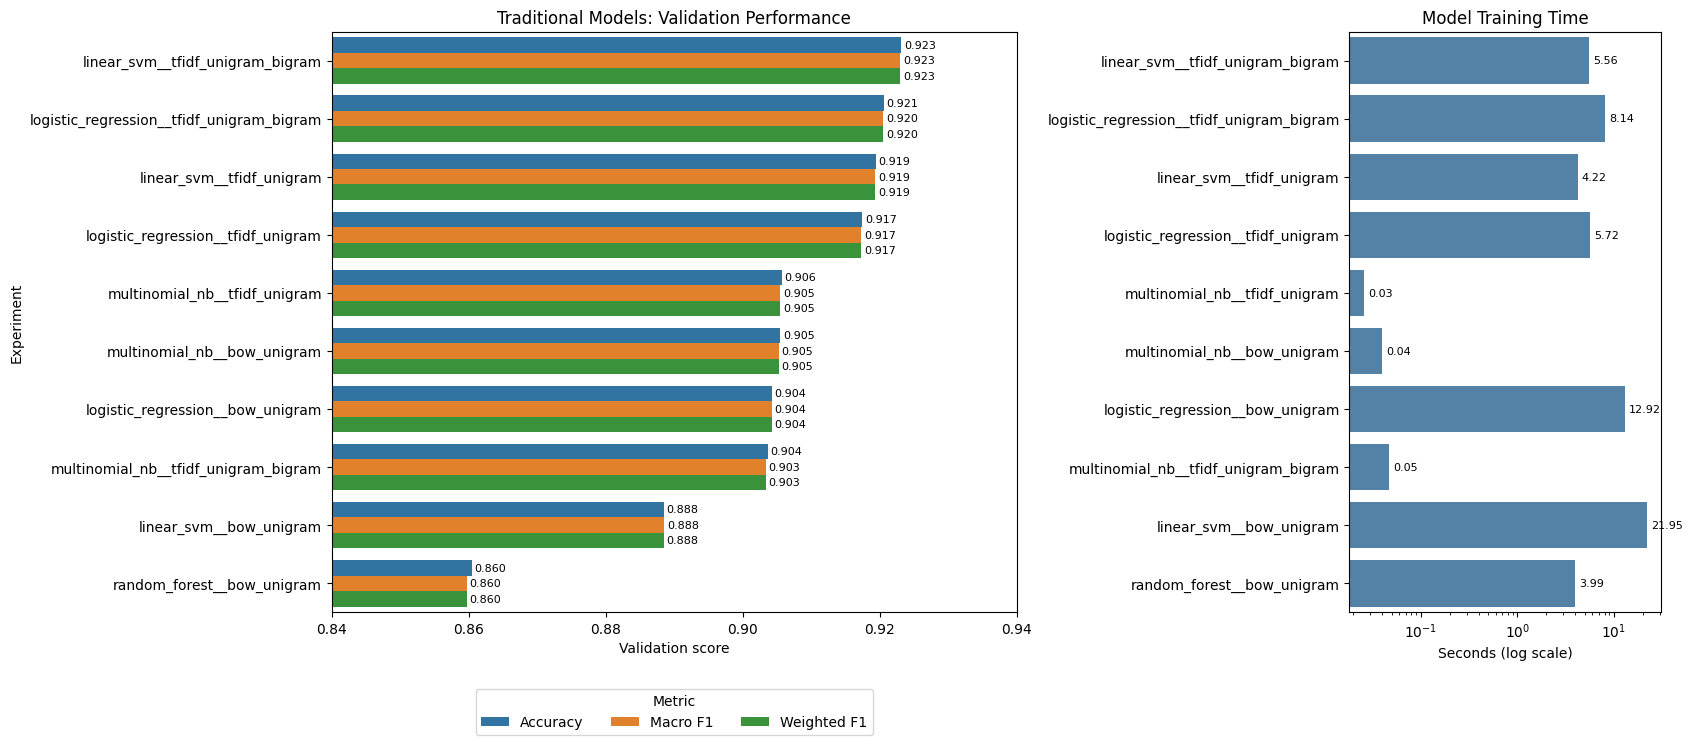

In [88]:
performance_metrics = ["Accuracy", "Macro F1", "Weighted F1"]
experiment_order = traditional_results["Experiment"].tolist()
plot_data = traditional_results.melt(
    id_vars="Experiment",
    value_vars=performance_metrics,
    var_name="Metric",
    value_name="Score",
)

fig, axes = plt.subplots(
    1, 2, figsize=(17, 8), gridspec_kw={"width_ratios": [2.2, 1]}
)
sns.barplot(
    data=plot_data,
    x="Score",
    y="Experiment",
    hue="Metric",
    order=experiment_order,
    ax=axes[0],
)
axes[0].set(
    title="Traditional Models: Validation Performance",
    xlabel="Validation score",
    ylabel="Experiment",
    xlim=(0.84, 0.94),
)
axes[0].set_xticks(np.arange(0.84, 0.95, 0.02))
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", padding=2, fontsize=8)
axes[0].legend(
    title="Metric", loc="upper center",
    bbox_to_anchor=(0.5, -0.12), ncol=3,
)

sns.barplot(
    data=traditional_results,
    x="Training time (s)",
    y="Experiment",
    order=experiment_order,
    color="steelblue",
    ax=axes[1],
)
axes[1].set(
    title="Model Training Time",
    xlabel="Seconds (log scale)",
    ylabel="",
)
axes[1].set_xscale("log")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3, fontsize=8)
plt.tight_layout(rect=(0, 0.05, 1, 1))
comparison_figure_path = FIGURE_DIR / "traditional_ml_validation_comparison.png"
plt.savefig(comparison_figure_path, dpi=150, bbox_inches="tight")
plt.show()


## 5.4. Candidate Traditional Models

Three provisional candidates are retained according to validation Macro F1, with Accuracy as the secondary criterion. The shortlist does not constitute final test evaluation, and no official test labels or test metrics are used in this section.


In [89]:
TRADITIONAL_CANDIDATE_COUNT = 3
traditional_candidates = traditional_results.head(
    TRADITIONAL_CANDIDATE_COUNT
)[
    [
        "Rank", "Experiment", "Model", "Feature set",
        "Accuracy", "Macro F1", "Weighted F1",
        "Training time (s)", "Validation prediction time (s)",
    ]
].copy()

display(
    traditional_candidates.round({
        "Accuracy": 4,
        "Macro F1": 4,
        "Weighted F1": 4,
        "Training time (s)": 2,
        "Validation prediction time (s)": 4,
    })
)

traditional_results.to_csv(
    METRIC_DIR / "traditional_ml_validation_results.csv", index=False
)
traditional_candidates.to_csv(
    METRIC_DIR / "traditional_ml_candidates.csv", index=False
)
print("Candidate experiment IDs:")
for experiment_id in traditional_candidates["Experiment"]:
    print(f"- {experiment_id}")
print("Primary selection metric: validation Macro F1")
print("Official test evaluations performed: 0")


,Rank,Experiment,Model,Feature set,Accuracy,Macro F1,Weighted F1,Training time (s),Validation prediction time (s)
0,1,linear_svm__tfidf_unigram_bigram,Linear SVM,tfidf_unigram_bigram,0.9231,0.9230,0.9230,5.56,0.0056
1,2,logistic_regression__tfidf_unigram_bigram,Logistic Regression,tfidf_unigram_bigram,0.9206,0.9205,0.9205,8.14,0.0068
2,3,linear_svm__tfidf_unigram,Linear SVM,tfidf_unigram,0.9194,0.9193,0.9193,4.22,0.0028


Candidate experiment IDs:
- linear_svm__tfidf_unigram_bigram
- logistic_regression__tfidf_unigram_bigram
- linear_svm__tfidf_unigram
Primary selection metric: validation Macro F1
Official test evaluations performed: 0


## 5.5. Preprocessing Ablation

The EDA cleaning trial changed word frequencies but did not measure classification performance. This auxiliary experiment compares the existing baseline (P0), removal of the six custom stopwords only (P1), and removal of standard English plus custom stopwords (P2). Each configuration creates separate train and validation text without modifying the prepared DataFrames. A new unigram–bigram TF-IDF vectorizer is fitted on its corresponding training text, followed by the same Linear SVM configuration (`C=1.0`). The official test set is not transformed or evaluated.


In [90]:
ablation_feature_config = FEATURE_CONFIGS["tfidf_unigram_bigram"].copy()
preprocessing_ablation_texts = {}
preprocessing_ablation_rows = []

for config_id, preprocessing_config in PREPROCESSING_ABLATION_CONFIGS.items():
    train_texts = train_split[TEXT_COLUMN].map(
        lambda text, config=preprocessing_config: preprocess_text(text, **config)
    )
    validation_texts = validation_split[TEXT_COLUMN].map(
        lambda text, config=preprocessing_config: preprocess_text(text, **config)
    )
    preprocessing_ablation_texts[config_id] = {
        "train": train_texts,
        "validation": validation_texts,
    }

    if config_id == "P0":
        assert train_texts.equals(train_split["text_traditional"])
        assert validation_texts.equals(validation_split["text_traditional"])

    start_time = perf_counter()
    vectorizer = build_vectorizer(ablation_feature_config)
    X_train_ablation = vectorizer.fit_transform(train_texts)
    X_validation_ablation = vectorizer.transform(validation_texts)
    feature_time = perf_counter() - start_time

    model = create_classifier("linear_svm")
    model, _, metrics = evaluate_on_validation(
        model,
        X_train_ablation,
        y_train,
        X_validation_ablation,
        y_validation,
    )
    preprocessing_ablation_rows.append({
        "Configuration": config_id,
        "Stopword rule": PREPROCESSING_ABLATION_DESCRIPTIONS[config_id],
        "Vocabulary size": len(vectorizer.vocabulary_),
        "Accuracy": metrics["Accuracy"],
        "Macro F1": metrics["Macro F1"],
        "Feature extraction time (s)": feature_time,
        "Classifier training time (s)": metrics["Training time (s)"],
        "Validation prediction time (s)": metrics["Validation prediction time (s)"],
    })

preprocessing_ablation_results = pd.DataFrame(preprocessing_ablation_rows)
display(preprocessing_ablation_results.round({
    "Accuracy": 4,
    "Macro F1": 4,
    "Feature extraction time (s)": 2,
    "Classifier training time (s)": 2,
    "Validation prediction time (s)": 4,
}))
preprocessing_ablation_results.to_csv(
    METRIC_DIR / "preprocessing_ablation_validation.csv", index=False
)
print("Official test evaluations performed: 0")


,Configuration,Stopword rule,Vocabulary size,Accuracy,Macro F1,Feature extraction time (s),Classifier training time (s),Validation prediction time (s)
0,P0,Existing baseline: no stopword removal,100000,0.9231,0.9230,8.13,6.48,0.0059
1,P1,Remove the six custom stopwords only,100000,0.9189,0.9188,8.22,5.68,0.0048
2,P2,Remove standard English and custom stopwords,100000,0.9204,0.9203,6.38,4.21,0.0034


Official test evaluations performed: 0


P0 achieved the highest validation result, with Accuracy **0.9231** and Macro F1 **0.9230**. Removing only the six custom stopwords in P1 reduced Macro F1 to **0.9188**, while removing standard and custom stopwords in P2 produced **0.9203**. The observed decreases relative to P0 were approximately **0.0042** and **0.0027**, respectively. These results provide no validation evidence for replacing the existing baseline in this fixed TF-IDF and Linear SVM experiment, so P0 is retained.


## 5.6. Controlled N-gram Comparison

The original unigram and unigram–bigram TF-IDF experiments use maximum feature limits of 50,000 and 100,000, respectively. The following comparison fixes the maximum at 50,000 and keeps all other vectorizer and Linear SVM settings unchanged. This controls one source of confounding, although the learned vocabularies may still contain different terms and n-grams.


In [91]:
CONTROLLED_NGRAM_CONFIGS = {
    "tfidf_unigram_50k_control": {
        **FEATURE_CONFIGS["tfidf_unigram"],
        "name": "TF-IDF unigram, 50k cap",
    },
    "tfidf_unigram_bigram_50k_control": {
        **FEATURE_CONFIGS["tfidf_unigram_bigram"],
        "name": "TF-IDF unigram + bigram, 50k cap",
        "max_features": 50_000,
    },
}
controlled_ngram_rows = []

for config_id, config in CONTROLLED_NGRAM_CONFIGS.items():
    start_time = perf_counter()
    vectorizer = build_vectorizer(config)
    X_train_control = vectorizer.fit_transform(train_split[TEXT_FEATURE_COLUMN])
    X_validation_control = vectorizer.transform(validation_split[TEXT_FEATURE_COLUMN])
    feature_time = perf_counter() - start_time

    model = create_classifier("linear_svm")
    model, _, metrics = evaluate_on_validation(
        model,
        X_train_control,
        y_train,
        X_validation_control,
        y_validation,
    )
    controlled_ngram_rows.append({
        "Configuration": config_id,
        "N-gram range": str(config["ngram_range"]),
        "Maximum features": config["max_features"],
        "Actual vocabulary size": len(vectorizer.vocabulary_),
        "Accuracy": metrics["Accuracy"],
        "Macro F1": metrics["Macro F1"],
        "Feature extraction time (s)": feature_time,
        "Classifier training time (s)": metrics["Training time (s)"],
        "Validation prediction time (s)": metrics["Validation prediction time (s)"],
    })

controlled_ngram_results = pd.DataFrame(controlled_ngram_rows)
display(controlled_ngram_results.round({
    "Accuracy": 4,
    "Macro F1": 4,
    "Feature extraction time (s)": 2,
    "Classifier training time (s)": 2,
    "Validation prediction time (s)": 4,
}))
controlled_ngram_results.to_csv(
    METRIC_DIR / "controlled_ngram_validation.csv", index=False
)
print("Official test evaluations performed: 0")


,Configuration,N-gram range,Maximum features,Actual vocabulary size,Accuracy,Macro F1,Feature extraction time (s),Classifier training time (s),Validation prediction time (s)
0,tfidf_unigram_50k_control,"(1, 1)",50000,40234,0.9194,0.9193,2.53,4.81,0.0052
1,tfidf_unigram_bigram_50k_control,"(1, 2)",50000,50000,0.9201,0.9200,8.35,5.29,0.0046


Official test evaluations performed: 0


With the maximum feature count fixed at 50,000, the unigram vectorizer produced **40,234** features and reached **0.9193** Macro F1. The unigram–bigram vectorizer reached the 50,000-feature cap and produced **0.9200** Macro F1, a difference of approximately **0.0007**. Its feature extraction time was **6.89 seconds**, compared with **2.15 seconds** for unigrams, and classifier training increased from **3.47** to **4.40 seconds**. This controlled result is consistent with a small validation improvement, but it does not isolate bigram information completely because the learned vocabularies are different.


## 5.7. Hyperparameter Sensitivity

This compact analysis varies one regularization parameter at a time while reusing the existing training and validation feature matrices. Linear SVM and Logistic Regression use the unigram–bigram TF-IDF representation, while Multinomial Naive Bayes uses unigram TF-IDF. All other model settings remain fixed, and the test set is not evaluated.


In [92]:
sensitivity_experiments = []
for value in (0.1, 1.0, 10.0):
    sensitivity_experiments.extend([
        {
            "Model key": "linear_svm",
            "Model": "Linear SVM",
            "Feature set": "tfidf_unigram_bigram",
            "Hyperparameter": "C",
            "Value": value,
        },
        {
            "Model key": "logistic_regression",
            "Model": "Logistic Regression",
            "Feature set": "tfidf_unigram_bigram",
            "Hyperparameter": "C",
            "Value": value,
        },
        {
            "Model key": "multinomial_nb",
            "Model": "Multinomial Naive Bayes",
            "Feature set": "tfidf_unigram",
            "Hyperparameter": "alpha",
            "Value": value,
        },
    ])

def create_sensitivity_classifier(model_key, value):
    '''Create a classifier while changing only the selected parameter.'''
    if model_key == "linear_svm":
        return LinearSVC(
            C=value, dual="auto", max_iter=5_000, tol=1e-4, random_state=SEED
        )
    if model_key == "logistic_regression":
        return LogisticRegression(
            C=value, solver="lbfgs", max_iter=1_000, tol=1e-4
        )
    if model_key == "multinomial_nb":
        return MultinomialNB(alpha=value)
    raise ValueError(f"Unsupported sensitivity model: {model_key}")

sensitivity_rows = []
for experiment in sensitivity_experiments:
    matrices = feature_sets[experiment["Feature set"]]["matrices"]
    model = create_sensitivity_classifier(
        experiment["Model key"], experiment["Value"]
    )
    model, _, metrics = evaluate_on_validation(
        model,
        matrices["train"],
        y_train,
        matrices["validation"],
        y_validation,
    )
    sensitivity_rows.append({
        "Model": experiment["Model"],
        "Representation": experiment["Feature set"],
        "Hyperparameter": experiment["Hyperparameter"],
        "Value": experiment["Value"],
        "Accuracy": metrics["Accuracy"],
        "Macro F1": metrics["Macro F1"],
        "Classifier training time (s)": metrics["Training time (s)"],
        "Validation prediction time (s)": metrics["Validation prediction time (s)"],
    })

hyperparameter_sensitivity_results = pd.DataFrame(sensitivity_rows)
display(hyperparameter_sensitivity_results.round({
    "Accuracy": 4,
    "Macro F1": 4,
    "Classifier training time (s)": 2,
    "Validation prediction time (s)": 4,
}))
hyperparameter_sensitivity_results.to_csv(
    METRIC_DIR / "hyperparameter_sensitivity_validation.csv", index=False
)
print("Official test evaluations performed: 0")


,Model,Representation,Hyperparameter,Value,Accuracy,Macro F1,Classifier training time (s),Validation prediction time (s)
0,Linear SVM,tfidf_unigram_bigram,C,0.1,0.9206,0.9204,4.62,0.0051
1,Logistic Regression,tfidf_unigram_bigram,C,0.1,0.9019,0.9016,2.79,0.0060
2,Multinomial Naive Bayes,tfidf_unigram,alpha,0.1,0.9068,0.9067,0.02,0.0036
3,Linear SVM,tfidf_unigram_bigram,C,1.0,0.9231,0.9230,4.89,0.0044
4,Logistic Regression,tfidf_unigram_bigram,C,1.0,0.9206,0.9205,6.85,0.0056
5,Multinomial Naive Bayes,tfidf_unigram,alpha,1.0,0.9056,0.9055,0.02,0.0030
6,Linear SVM,tfidf_unigram_bigram,C,10.0,0.9076,0.9075,8.28,0.0040
7,Logistic Regression,tfidf_unigram_bigram,C,10.0,0.9197,0.9196,10.03,0.0048
8,Multinomial Naive Bayes,tfidf_unigram,alpha,10.0,0.8984,0.8981,0.02,0.0034


Official test evaluations performed: 0


Within the tested values, Linear SVM performed best at **C=1.0** with **0.9230** Macro F1; performance fell to **0.9204** at `C=0.1` and **0.9075** at `C=10.0`. Logistic Regression also performed best at **C=1.0** (**0.9205**), while `C=10.0` was close at **0.9196** and `C=0.1` was lower at **0.9016**. Multinomial Naive Bayes achieved its highest tested Macro F1 at **alpha=0.1** (**0.9067**), compared with **0.9055** at `alpha=1.0` and **0.8981** at `alpha=10.0`. These results describe a small sensitivity check rather than an exhaustive search.


## 5.8. Traditional ML Observations

For Multinomial Naive Bayes, the unigram Bag-of-Words and TF-IDF results were almost identical: validation Macro F1 was **0.9053** and **0.9055**, respectively. Logistic Regression and Linear SVM benefited more from TF-IDF. Logistic Regression increased from **0.9042** Macro F1 with Bag-of-Words to **0.9173** with unigram TF-IDF, while Linear SVM increased from **0.8885** to **0.9193**.

The original unigram–bigram comparison used a 100,000-feature cap instead of the unigram cap of 50,000. Linear SVM reached **0.9230** Macro F1 with this representation, compared with **0.9193** for unigram TF-IDF, but the original result cannot attribute the difference to bigrams alone. In the controlled 50,000-feature comparison, the corresponding scores were **0.9200** and **0.9193**, respectively.

Accuracy and Macro F1 were close for every model because the validation classes are nearly balanced. Linear SVM with unigram–bigram TF-IDF ranked first by Macro F1 (**0.9230**) and trained in **4.61 seconds** in the recorded baseline run. Random Forest had the lowest Macro F1 (**0.8597**) and trained in **3.15 seconds**, showing that classifier training time alone did not indicate stronger validation performance. These times exclude feature extraction and are descriptive for the recorded environment.

The corrected P0 preprocessing changed the stored traditional text because the one-character filter became active. Exact before-and-after comparisons nevertheless found **zero changed entries across all nine original sparse matrices** and **zero changed predictions across all ten baseline validation experiments**. The original baseline metrics therefore remain numerically valid after rerunning, while the corrected P1 and P2 ablation results replace the previous invalid comparison.


# **6. Pretrained Text Representations**
---
This section creates dense document representations from two pretrained sources: GloVe word vectors and a frozen DistilBERT encoder. The existing train, validation, and test membership is preserved. These models supply fixed representations only; no downstream classifier is trained and DistilBERT weights are not fine-tuned.

All pretrained resources are downloaded programmatically and cached under the project `data/pretrained/` directory. Generated embeddings are saved as NumPy arrays under `features/pretrained/`.


## 6.1. GloVe Mean-Pooled Embeddings

The [Gensim downloader](https://radimrehurek.com/gensim/downloader.html) provides `glove-wiki-gigaword-100`, an uncased model with 400,000 word vectors and 100 dimensions. Each news record is lowercased and tokenized with the EDA tokenizer. Its document vector is the arithmetic mean of all recognized token vectors.

Out-of-vocabulary tokens are skipped. A document with no recognized token receives an all-zero vector, preventing missing values or shape inconsistencies. Coverage is reported by token occurrence and by unique token type for each split.


In [93]:
PRETRAINED_FEATURE_DIR = FEATURE_DIR / "pretrained"
HF_CACHE_DIR = PRETRAINED_DATA_DIR / "huggingface"

for directory in (
    PRETRAINED_FEATURE_DIR,
    GENSIM_CACHE_DIR,
    HF_CACHE_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

GLOVE_MODEL_NAME = "glove-wiki-gigaword-100"
glove_vectors = gensim_api.load(GLOVE_MODEL_NAME)
GLOVE_DIMENSION = glove_vectors.vector_size
print(f"GloVe model: {GLOVE_MODEL_NAME}")
print(f"Embedding dimension: {GLOVE_DIMENSION}")
print(f"Pretrained vocabulary size: {len(glove_vectors):,}")
print(f"Gensim cache: {GENSIM_CACHE_DIR.as_posix()}")


GloVe model: glove-wiki-gigaword-100
Embedding dimension: 100
Pretrained vocabulary size: 400,000
Gensim cache: data/pretrained/gensim


In [94]:
def extract_glove_embeddings(texts, word_vectors):
    """Mean-pool recognized GloVe tokens and collect coverage statistics."""
    embeddings = np.zeros(
        (len(texts), word_vectors.vector_size),
        dtype=np.float32,
    )
    vocabulary = word_vectors.key_to_index
    total_tokens = 0
    recognized_tokens = 0
    documents_without_vectors = 0
    unique_tokens = set()
    unique_recognized_tokens = set()

    for row, text in enumerate(texts):
        tokens = tokenize_text(text)
        known_tokens = [token for token in tokens if token in vocabulary]

        total_tokens += len(tokens)
        recognized_tokens += len(known_tokens)
        unique_tokens.update(tokens)
        unique_recognized_tokens.update(known_tokens)

        if known_tokens:
            embeddings[row] = word_vectors[known_tokens].mean(axis=0)
        else:
            documents_without_vectors += 1

    statistics = {
        "Total tokens": total_tokens,
        "Recognized tokens": recognized_tokens,
        "OOV tokens": total_tokens - recognized_tokens,
        "Token coverage (%)": (
            100 * recognized_tokens / total_tokens if total_tokens else 0
        ),
        "OOV tokens (%)": (
            100 * (total_tokens - recognized_tokens) / total_tokens
            if total_tokens else 0
        ),
        "Unique tokens": len(unique_tokens),
        "Recognized unique tokens": len(unique_recognized_tokens),
        "Unique-token coverage (%)": (
            100 * len(unique_recognized_tokens) / len(unique_tokens)
            if unique_tokens else 0
        ),
        "Documents without vectors": documents_without_vectors,
    }
    return embeddings, statistics


In [95]:
representation_texts = {
    "train": train_split["text_minimal"],
    "validation": validation_split["text_minimal"],
    "test": test_split["text_minimal"],
}
glove_embeddings = {}
glove_coverage_rows = []
pretrained_file_rows = []

for split_name, texts in representation_texts.items():
    start_time = perf_counter()
    embeddings, statistics = extract_glove_embeddings(texts, glove_vectors)
    elapsed_time = perf_counter() - start_time
    path = PRETRAINED_FEATURE_DIR / (
        f"{GLOVE_MODEL_NAME.replace('-', '_')}_{split_name}.npy"
    )
    np.save(path, embeddings)

    glove_embeddings[split_name] = embeddings
    glove_coverage_rows.append({
        "Split": split_name.title(),
        **statistics,
        "Extraction time (s)": elapsed_time,
    })
    pretrained_file_rows.append({
        "Representation": "GloVe mean pooling",
        "Split": split_name.title(),
        "Shape": str(embeddings.shape),
        "File": path.as_posix(),
        "Size (MB)": path.stat().st_size / (1024 ** 2),
    })

glove_coverage = pd.DataFrame(glove_coverage_rows)
display(glove_coverage.round({
    "Token coverage (%)": 2,
    "OOV tokens (%)": 2,
    "Unique-token coverage (%)": 2,
    "Extraction time (s)": 2,
}))


,Split,Total tokens,Recognized tokens,OOV tokens,Token coverage (%),OOV tokens (%),Unique tokens,Recognized unique tokens,Unique-token coverage (%),Documents without vectors,Extraction time (s)
0,Train,4030520,3995809,34711,99.14,0.86,61910,53267,86.04,0,5.80
1,Validation,445736,441946,3790,99.15,0.85,26489,24791,93.59,0,0.99
2,Test,282814,280404,2410,99.15,0.85,21581,20443,94.73,0,0.48


## 6.2. Frozen DistilBERT Embeddings

The [`distilbert-base-uncased`](https://huggingface.co/distilbert/distilbert-base-uncased) encoder produces a contextual hidden state for each input token. Text uses `text_minimal`, preserving punctuation and contextual wording for the pretrained tokenizer. The token-length audit below uses this exact tokenizer before evaluating the fixed 128-token limit.

Document vectors use masked mean pooling over the last hidden states of all non-padding tokens. The model remains frozen in evaluation mode and runs inside `torch.no_grad()`. No classification head, labels, gradient updates, or fine-tuning are used.


In [96]:
from transformers.utils import logging as transformers_logging

transformers_logging.set_verbosity_error()

DISTILBERT_MODEL_NAME = "distilbert-base-uncased"
DISTILBERT_MAX_LENGTH = 128
DISTILBERT_BATCH_SIZE = 64 if device.type == "cuda" else 8

distilbert_tokenizer = AutoTokenizer.from_pretrained(
    DISTILBERT_MODEL_NAME,
    cache_dir=str(HF_CACHE_DIR),
)
distilbert_model = AutoModel.from_pretrained(
    DISTILBERT_MODEL_NAME,
    cache_dir=str(HF_CACHE_DIR),
)
distilbert_model.requires_grad_(False)
distilbert_model.to(device)
distilbert_model.eval()

DISTILBERT_DIMENSION = distilbert_model.config.dim
print(f"DistilBERT model: {DISTILBERT_MODEL_NAME}")
print(f"Device: {device}")
print(f"Batch size: {DISTILBERT_BATCH_SIZE}")
print(f"Maximum sequence length: {DISTILBERT_MAX_LENGTH}")
print(f"Embedding dimension: {DISTILBERT_DIMENSION}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBERT model: distilbert-base-uncased
Device: cuda
Batch size: 64
Maximum sequence length: 128
Embedding dimension: 768


### 6.2.1. Token-Length Audit

Whitespace word counts do not measure DistilBERT subword length. This audit tokenizes the training subset in batches with the same tokenizer used for embedding extraction. Special tokens are included, while padding and truncation are disabled. Validation and test text are not used to choose the sequence length.


,Split,Samples,Mean,Median,90th percentile,95th percentile,99th percentile,Maximum,Samples above 128,Samples above 128 (%)
0,Train,107973,50.48,49.0,65.0,72.0,96.0,232,269,0.25


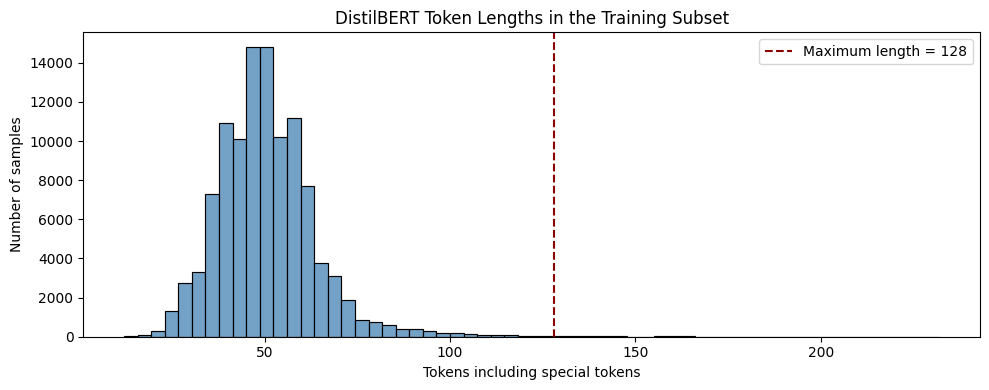

In [97]:
TOKEN_AUDIT_BATCH_SIZE = 512
train_token_lengths = np.empty(len(train_split), dtype=np.int32)
train_audit_texts = train_split["text_minimal"]

for start in range(0, len(train_audit_texts), TOKEN_AUDIT_BATCH_SIZE):
    end = min(start + TOKEN_AUDIT_BATCH_SIZE, len(train_audit_texts))
    encoded = distilbert_tokenizer(
        train_audit_texts.iloc[start:end].tolist(),
        add_special_tokens=True,
        padding=False,
        truncation=False,
        return_attention_mask=False,
        return_token_type_ids=False,
    )
    train_token_lengths[start:end] = [
        len(input_ids) for input_ids in encoded["input_ids"]
    ]

exceeds_max_length = train_token_lengths > DISTILBERT_MAX_LENGTH
token_length_audit = pd.DataFrame([{
    "Split": "Train",
    "Samples": len(train_token_lengths),
    "Mean": train_token_lengths.mean(),
    "Median": np.median(train_token_lengths),
    "90th percentile": np.percentile(train_token_lengths, 90),
    "95th percentile": np.percentile(train_token_lengths, 95),
    "99th percentile": np.percentile(train_token_lengths, 99),
    "Maximum": train_token_lengths.max(),
    "Samples above 128": exceeds_max_length.sum(),
    "Samples above 128 (%)": 100 * exceeds_max_length.mean(),
}])
display(token_length_audit.round(2))
token_length_audit.to_csv(
    TABLE_DIR / "distilbert_token_length_audit.csv", index=False
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(train_token_lengths, bins=60, color="steelblue", ax=ax)
ax.axvline(
    DISTILBERT_MAX_LENGTH,
    color="darkred",
    linestyle="--",
    label=f"Maximum length = {DISTILBERT_MAX_LENGTH}",
)
ax.set(
    title="DistilBERT Token Lengths in the Training Subset",
    xlabel="Tokens including special tokens",
    ylabel="Number of samples",
)
ax.legend()
plt.tight_layout()
token_length_figure_path = FIGURE_DIR / "distilbert_token_length_distribution.png"
plt.savefig(token_length_figure_path, dpi=150, bbox_inches="tight")
plt.show()


Training sequences had a mean length of **50.48** tokens and a median of **49**. The 90th, 95th, and 99th percentiles were **65**, **72**, and **96** tokens, while the maximum was **232**. Only **269 of 107,973 training samples (0.25%)** exceeded 128 tokens. The current limit is therefore retained because truncation affects a small part of the training subset and reduces extraction memory and computation. A larger limit may still be evaluated separately if later error analysis indicates that long records are important; changing it would require regenerating all DistilBERT embeddings and their downstream results.


### 6.2.2. Frozen Embedding Extraction

Tokenization uses dynamic padding within each batch and truncation at `DISTILBERT_MAX_LENGTH`. Attention masks exclude padding from mean pooling. Extraction is batched to control GPU and RAM use, and saved arrays use `float32`.


In [98]:
def extract_distilbert_embeddings(
    texts,
    tokenizer,
    model,
    extraction_device,
    batch_size,
    max_length,
):
    """Create masked mean-pooled embeddings with frozen DistilBERT."""
    embeddings = np.empty(
        (len(texts), model.config.dim),
        dtype=np.float32,
    )
    total_batches = (len(texts) + batch_size - 1) // batch_size

    for batch_number, start in enumerate(
        range(0, len(texts), batch_size),
        start=1,
    ):
        end = min(start + batch_size, len(texts))
        batch_texts = texts.iloc[start:end].tolist()
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_attention_mask=True,
            return_tensors="pt",
        )
        encoded = {
            name: tensor.to(extraction_device)
            for name, tensor in encoded.items()
        }

        with torch.no_grad():
            hidden_states = model(**encoded).last_hidden_state
            attention_mask = encoded["attention_mask"].unsqueeze(-1)
            attention_mask = attention_mask.to(hidden_states.dtype)
            pooled = (hidden_states * attention_mask).sum(dim=1)
            pooled = pooled / attention_mask.sum(dim=1).clamp(min=1)

        embeddings[start:end] = pooled.cpu().numpy().astype(
            np.float32,
            copy=False,
        )

        if batch_number % 250 == 0 or batch_number == total_batches:
            print(f"Processed {batch_number:,}/{total_batches:,} batches.")

    return embeddings


In [99]:
distilbert_embeddings = []
distilbert_extraction_rows = []

for split_name, texts in representation_texts.items():
    print(f"Extracting {split_name} DistilBERT embeddings...")
    start_time = perf_counter()
    embeddings = extract_distilbert_embeddings(
        texts,
        distilbert_tokenizer,
        distilbert_model,
        device,
        DISTILBERT_BATCH_SIZE,
        DISTILBERT_MAX_LENGTH,
    )
    elapsed_time = perf_counter() - start_time
    path = PRETRAINED_FEATURE_DIR / (
        f"{DISTILBERT_MODEL_NAME.replace('-', '_')}_mean_{split_name}.npy"
    )
    np.save(path, embeddings)

    distilbert_embeddings.append(embeddings)
    distilbert_extraction_rows.append({
        "Split": split_name.title(),
        "Samples": len(texts),
        "Embedding dimension": embeddings.shape[1],
        "Extraction time (s)": elapsed_time,
    })
    pretrained_file_rows.append({
        "Representation": "DistilBERT masked mean",
        "Split": split_name.title(),
        "Shape": str(embeddings.shape),
        "File": path.as_posix(),
        "Size (MB)": path.stat().st_size / (1024 ** 2),
    })

distilbert_embeddings = {
    split_name: embeddings
    for split_name, embeddings in zip(
        representation_texts,
        distilbert_embeddings,
    )
}
display(pd.DataFrame(distilbert_extraction_rows).round({
    "Extraction time (s)": 2,
}))

distilbert_model.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Extracting train DistilBERT embeddings...
Processed 250/1,688 batches.
Processed 500/1,688 batches.
Processed 750/1,688 batches.
Processed 1,000/1,688 batches.
Processed 1,250/1,688 batches.
Processed 1,500/1,688 batches.
Processed 1,688/1,688 batches.
Extracting validation DistilBERT embeddings...
Processed 188/188 batches.
Extracting test DistilBERT embeddings...
Processed 119/119 batches.


,Split,Samples,Embedding dimension,Extraction time (s)
0,Train,107973,768,175.74
1,Validation,11987,768,19.55
2,Test,7600,768,12.62


## 6.3. Representation Summary

The summary lists the dimensions and saved paths for every split. GloVe and DistilBERT features are dense `float32` arrays based on `text_minimal`, and their row order follows the prepared DataFrames. Reported embedding extraction times include different operations from classifier training times, so they should not be compared as equivalent costs. All timing values describe the recorded runtime environment shown in Phase 1.


In [100]:
pretrained_feature_files = pd.DataFrame(pretrained_file_rows)
display(pretrained_feature_files.round({"Size (MB)": 2}))

pretrained_representation_summary = pd.DataFrame([
    {
        "Representation": "GloVe mean pooling",
        "Model": GLOVE_MODEL_NAME,
        "Pooling": "Mean of recognized word vectors",
        "Dimension": GLOVE_DIMENSION,
        "Train shape": str(glove_embeddings["train"].shape),
        "Validation shape": str(glove_embeddings["validation"].shape),
        "Test shape": str(glove_embeddings["test"].shape),
    },
    {
        "Representation": "DistilBERT masked mean",
        "Model": DISTILBERT_MODEL_NAME,
        "Pooling": "Attention-mask mean of last hidden states",
        "Dimension": DISTILBERT_DIMENSION,
        "Train shape": str(distilbert_embeddings["train"].shape),
        "Validation shape": str(distilbert_embeddings["validation"].shape),
        "Test shape": str(distilbert_embeddings["test"].shape),
    },
])
display(pretrained_representation_summary)

glove_coverage.to_csv(
    TABLE_DIR / "glove_vocabulary_coverage.csv",
    index=False,
)
pretrained_feature_files.to_csv(
    TABLE_DIR / "pretrained_feature_files.csv",
    index=False,
)
pretrained_representation_summary.to_csv(
    TABLE_DIR / "pretrained_representation_summary.csv",
    index=False,
)
print("Downstream classifiers trained in this section: 0")
print("DistilBERT parameters updated: 0")


,Representation,Split,Shape,File,Size (MB)
0,GloVe mean pooling,Train,"(107973, 100)",features/pretrained/glove_wiki_gigaword_100_tr...,41.19
1,GloVe mean pooling,Validation,"(11987, 100)",features/pretrained/glove_wiki_gigaword_100_va...,4.57
2,GloVe mean pooling,Test,"(7600, 100)",features/pretrained/glove_wiki_gigaword_100_te...,2.90
3,DistilBERT masked mean,Train,"(107973, 768)",features/pretrained/distilbert_base_uncased_me...,316.33
4,DistilBERT masked mean,Validation,"(11987, 768)",features/pretrained/distilbert_base_uncased_me...,35.12
5,DistilBERT masked mean,Test,"(7600, 768)",features/pretrained/distilbert_base_uncased_me...,22.27


,Representation,Model,Pooling,Dimension,Train shape,Validation shape,Test shape
0,GloVe mean pooling,glove-wiki-gigaword-100,Mean of recognized word vectors,100,"(107973, 100)","(11987, 100)","(7600, 100)"
1,DistilBERT masked mean,distilbert-base-uncased,Attention-mask mean of last hidden states,768,"(107973, 768)","(11987, 768)","(7600, 768)"


Downstream classifiers trained in this section: 0
DistilBERT parameters updated: 0


## 6.4. Embedding Integrity Checks

The saved GloVe and DistilBERT arrays are opened with memory mapping to avoid duplicate full-size allocations. Each file is checked for existence, shape, dimension, `float32` dtype, and finite values. Row order is tested at the first, middle, and last positions of every split by recomputing those rows from the corresponding `text_minimal` records and comparing them with the saved vectors.


In [101]:
integrity_split_frames = {
    "train": train_split,
    "validation": validation_split,
    "test": test_split,
}
embedding_specs = {
    "GloVe mean pooling": {
        "model": GLOVE_MODEL_NAME,
        "pooling": "Mean of recognized word vectors",
        "dimension": GLOVE_DIMENSION,
        "file_prefix": GLOVE_MODEL_NAME.replace("-", "_"),
        "file_suffix": "",
        "maximum sequence length": pd.NA,
    },
    "DistilBERT masked mean": {
        "model": DISTILBERT_MODEL_NAME,
        "pooling": "Attention-mask mean of last hidden states",
        "dimension": DISTILBERT_DIMENSION,
        "file_prefix": DISTILBERT_MODEL_NAME.replace("-", "_"),
        "file_suffix": "_mean",
        "maximum sequence length": DISTILBERT_MAX_LENGTH,
    },
}

embedding_manifest_rows = []
integrity_rows = []
distilbert_model.to(device)
distilbert_model.eval()

try:
    for representation, spec in embedding_specs.items():
        for split_name, frame in integrity_split_frames.items():
            source_texts = frame["text_minimal"]
            assert source_texts.index.equals(frame.index)
            file_path = PRETRAINED_FEATURE_DIR / (
                f"{spec['file_prefix']}{spec['file_suffix']}_{split_name}.npy"
            )
            assert file_path.is_file(), f"Missing embedding file: {file_path}"

            saved_array = np.load(file_path, mmap_mode="r", allow_pickle=False)
            expected_shape = (len(frame), spec["dimension"])
            assert saved_array.shape == expected_shape, (
                f"Unexpected shape for {file_path}: {saved_array.shape}"
            )
            assert saved_array.dtype == np.float32, (
                f"Unexpected dtype for {file_path}: {saved_array.dtype}"
            )
            assert np.isfinite(saved_array).all(), (
                f"Non-finite values found in {file_path}"
            )

            positions = np.array([0, len(frame) // 2, len(frame) - 1])
            selected_texts = source_texts.iloc[positions].reset_index(drop=True)
            if representation == "GloVe mean pooling":
                recomputed_rows, _ = extract_glove_embeddings(
                    selected_texts, glove_vectors
                )
                tolerance = 1e-6
            else:
                recomputed_rows = extract_distilbert_embeddings(
                    selected_texts,
                    distilbert_tokenizer,
                    distilbert_model,
                    device,
                    batch_size=len(selected_texts),
                    max_length=DISTILBERT_MAX_LENGTH,
                )
                tolerance = 1e-5
            assert np.allclose(
                saved_array[positions], recomputed_rows, atol=tolerance, rtol=1e-5
            ), f"Row-order verification failed for {file_path}"

            embedding_manifest_rows.append({
                "Representation": representation,
                "Pretrained model": spec["model"],
                "Pooling method": spec["pooling"],
                "Source text column": "text_minimal",
                "Split": split_name.title(),
                "Number of samples": saved_array.shape[0],
                "Embedding dimension": saved_array.shape[1],
                "Dtype": str(saved_array.dtype),
                "File path": file_path.as_posix(),
                "File size (MB)": file_path.stat().st_size / (1024 ** 2),
                "Maximum sequence length": spec["maximum sequence length"],
            })
            integrity_rows.append({
                "Representation": representation,
                "Split": split_name.title(),
                "File": "Passed",
                "Shape": "Passed",
                "Dtype": "Passed",
                "Finite values": "Passed",
                "Sampled row order": "Passed",
            })
finally:
    distilbert_model.to("cpu")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

embedding_manifest = pd.DataFrame(embedding_manifest_rows)
embedding_integrity_summary = pd.DataFrame(integrity_rows)
embedding_manifest.to_csv(
    TABLE_DIR / "pretrained_embedding_manifest.csv", index=False
)
display(embedding_integrity_summary)
display(embedding_manifest.round({"File size (MB)": 2}))
print("All embedding integrity checks passed.")
print("Downstream classifiers trained in this section: 0")


Processed 1/1 batches.
Processed 1/1 batches.
Processed 1/1 batches.


,Representation,Split,File,Shape,Dtype,Finite values,Sampled row order
0,GloVe mean pooling,Train,Passed,Passed,Passed,Passed,Passed
1,GloVe mean pooling,Validation,Passed,Passed,Passed,Passed,Passed
2,GloVe mean pooling,Test,Passed,Passed,Passed,Passed,Passed
3,DistilBERT masked mean,Train,Passed,Passed,Passed,Passed,Passed
4,DistilBERT masked mean,Validation,Passed,Passed,Passed,Passed,Passed
5,DistilBERT masked mean,Test,Passed,Passed,Passed,Passed,Passed


,Representation,Pretrained model,Pooling method,Source text column,Split,Number of samples,Embedding dimension,Dtype,File path,File size (MB),Maximum sequence length
0,GloVe mean pooling,glove-wiki-gigaword-100,Mean of recognized word vectors,text_minimal,Train,107973,100,float32,features/pretrained/glove_wiki_gigaword_100_tr...,41.19,<NA>
1,GloVe mean pooling,glove-wiki-gigaword-100,Mean of recognized word vectors,text_minimal,Validation,11987,100,float32,features/pretrained/glove_wiki_gigaword_100_va...,4.57,<NA>
2,GloVe mean pooling,glove-wiki-gigaword-100,Mean of recognized word vectors,text_minimal,Test,7600,100,float32,features/pretrained/glove_wiki_gigaword_100_te...,2.90,<NA>
3,DistilBERT masked mean,distilbert-base-uncased,Attention-mask mean of last hidden states,text_minimal,Train,107973,768,float32,features/pretrained/distilbert_base_uncased_me...,316.33,128
4,DistilBERT masked mean,distilbert-base-uncased,Attention-mask mean of last hidden states,text_minimal,Validation,11987,768,float32,features/pretrained/distilbert_base_uncased_me...,35.12,128
5,DistilBERT masked mean,distilbert-base-uncased,Attention-mask mean of last hidden states,text_minimal,Test,7600,768,float32,features/pretrained/distilbert_base_uncased_me...,22.27,128


All embedding integrity checks passed.
Downstream classifiers trained in this section: 0


# **7. Classification Using Pretrained Embeddings**
---
This section evaluates whether the fixed GloVe and DistilBERT document embeddings support effective traditional classification. Logistic Regression and Linear SVM are trained on the established training subset and evaluated on validation data only. The official test set remains reserved for final evaluation.

Multinomial Naive Bayes is not used because the dense embeddings contain signed continuous values rather than non-negative token counts. Random Forest is omitted because fitting a tree ensemble on 107,973 dense vectors, particularly the 768-dimensional DistilBERT representation, would add substantial computation without serving the primary comparison.


## 7.1. Experimental Design

Both classifiers use `C=1.0`, matching the original traditional baseline. Logistic Regression uses the `sag` solver because the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) recommends SAG/SAGA for large datasets. Linear SVM uses the primal formulation (`dual=False`) because the number of training samples is much larger than the embedding dimension. A tolerance of `1e-3` is used for both models after a local runtime check showed convergence without warnings on the dense embeddings. No embedding-specific hyperparameter search is performed.

Training time and validation prediction time measure only the downstream classifier. GloVe and DistilBERT extraction times were reported separately in Section 6 and are not added to these measurements.


In [102]:
PRETRAINED_CLASSIFIER_SETTINGS = {
    "logistic_regression": "C=1.0, L2, sag, tol=1e-3, max_iter=1000",
    "linear_svm": "C=1.0, squared hinge, dual=False, tol=1e-3, max_iter=5000",
}

def create_pretrained_embedding_classifier(model_key):
    """Create a classifier suited to dense pretrained embeddings."""
    if model_key == "logistic_regression":
        return LogisticRegression(
            C=1.0,
            solver="sag",
            max_iter=1_000,
            tol=1e-3,
            random_state=SEED,
        )
    if model_key == "linear_svm":
        return LinearSVC(
            C=1.0,
            dual=False,
            max_iter=5_000,
            tol=1e-3,
            random_state=SEED,
        )
    raise ValueError(f"Unsupported pretrained-embedding classifier: {model_key}")

PRETRAINED_CLASSIFIER_EXPERIMENTS = [
    {
        "Experiment": f"{model_key}__{feature_key}",
        "Model key": model_key,
        "Model": model_name,
        "Feature set": feature_key,
        "Settings": PRETRAINED_CLASSIFIER_SETTINGS[model_key],
    }
    for feature_key in ("glove_mean_100d", "distilbert_mean_768d")
    for model_key, model_name in (
        ("logistic_regression", "Logistic Regression"),
        ("linear_svm", "Linear SVM"),
    )
]
display(pd.DataFrame(PRETRAINED_CLASSIFIER_EXPERIMENTS).drop(columns="Model key"))


,Experiment,Model,Feature set,Settings
0,logistic_regression__glove_mean_100d,Logistic Regression,glove_mean_100d,"C=1.0, L2, sag, tol=1e-3, max_iter=1000"
1,linear_svm__glove_mean_100d,Linear SVM,glove_mean_100d,"C=1.0, squared hinge, dual=False, tol=1e-3, ma..."
2,logistic_regression__distilbert_mean_768d,Logistic Regression,distilbert_mean_768d,"C=1.0, L2, sag, tol=1e-3, max_iter=1000"
3,linear_svm__distilbert_mean_768d,Linear SVM,distilbert_mean_768d,"C=1.0, squared hinge, dual=False, tol=1e-3, ma..."


## 7.2. Loading the Saved Embeddings

Only train and validation arrays are opened. Memory mapping avoids creating an additional full-size copy before a classifier requests one. Shape, row count, dimension, dtype, and finite-value checks protect the alignment verified in Section 6.4.


In [103]:
PRETRAINED_CLASSIFICATION_FEATURES = {
    "glove_mean_100d": {
        "name": "GloVe mean pooling (100D)",
        "dimension": GLOVE_DIMENSION,
        "paths": {
            split_name: PRETRAINED_FEATURE_DIR / (
                f"{GLOVE_MODEL_NAME.replace('-', '_')}_{split_name}.npy"
            )
            for split_name in ("train", "validation")
        },
    },
    "distilbert_mean_768d": {
        "name": "DistilBERT masked mean (768D)",
        "dimension": DISTILBERT_DIMENSION,
        "paths": {
            split_name: PRETRAINED_FEATURE_DIR / (
                f"{DISTILBERT_MODEL_NAME.replace('-', '_')}_mean_{split_name}.npy"
            )
            for split_name in ("train", "validation")
        },
    },
}

embedding_classification_rows = []
for feature_key, feature_spec in PRETRAINED_CLASSIFICATION_FEATURES.items():
    matrices = {
        split_name: np.load(file_path, mmap_mode="r", allow_pickle=False)
        for split_name, file_path in feature_spec["paths"].items()
    }
    expected_shapes = {
        "train": (len(train_split), feature_spec["dimension"]),
        "validation": (len(validation_split), feature_spec["dimension"]),
    }
    for split_name, matrix in matrices.items():
        assert matrix.shape == expected_shapes[split_name]
        assert matrix.dtype == np.float32
        assert np.isfinite(matrix).all()
    feature_spec["matrices"] = matrices
    embedding_classification_rows.append({
        "Feature set": feature_key,
        "Representation": feature_spec["name"],
        "Train shape": str(matrices["train"].shape),
        "Validation shape": str(matrices["validation"].shape),
        "Minimum training value": float(matrices["train"].min()),
        "Maximum training value": float(matrices["train"].max()),
    })

embedding_classification_summary = pd.DataFrame(embedding_classification_rows)
display(embedding_classification_summary.round({
    "Minimum training value": 4,
    "Maximum training value": 4,
}))
print("Official test embedding arrays loaded in this section: 0")


,Feature set,Representation,Train shape,Validation shape,Minimum training value,Maximum training value
0,glove_mean_100d,GloVe mean pooling (100D),"(107973, 100)","(11987, 100)",-2.7545,2.1088
1,distilbert_mean_768d,DistilBERT masked mean (768D),"(107973, 768)","(11987, 768)",-4.7079,1.5844


Official test embedding arrays loaded in this section: 0


## 7.3. Training and Validation Evaluation

The evaluation function from Section 5 is reused so that metric definitions and timing boundaries remain consistent. Each model is fitted on the training embedding and predicts the validation embedding. All five classification metrics are calculated with the same four-class label order.


In [104]:
fitted_pretrained_classifiers = {}
pretrained_validation_predictions = {}
pretrained_classifier_rows = []

for experiment in PRETRAINED_CLASSIFIER_EXPERIMENTS:
    experiment_id = experiment["Experiment"]
    feature_key = experiment["Feature set"]
    matrices = PRETRAINED_CLASSIFICATION_FEATURES[feature_key]["matrices"]
    model = create_pretrained_embedding_classifier(experiment["Model key"])

    print(f"Running {experiment_id}...")
    model, predictions, metrics = evaluate_on_validation(
        model,
        matrices["train"],
        y_train,
        matrices["validation"],
        y_validation,
    )
    fitted_pretrained_classifiers[experiment_id] = model
    pretrained_validation_predictions[experiment_id] = predictions
    pretrained_classifier_rows.append({
        key: value for key, value in experiment.items() if key != "Model key"
    } | metrics)

pretrained_classifier_results = pd.DataFrame(
    pretrained_classifier_rows
).sort_values(
    ["Macro F1", "Accuracy"],
    ascending=False,
).reset_index(drop=True)
pretrained_classifier_results.insert(
    0, "Rank", np.arange(1, len(pretrained_classifier_results) + 1)
)

display(
    pretrained_classifier_results[
        [
            "Rank", "Experiment", "Model", "Feature set",
            "Accuracy", "Macro Precision", "Macro Recall",
            "Macro F1", "Weighted F1", "Training time (s)",
            "Validation prediction time (s)",
        ]
    ].round({
        "Accuracy": 4,
        "Macro Precision": 4,
        "Macro Recall": 4,
        "Macro F1": 4,
        "Weighted F1": 4,
        "Training time (s)": 2,
        "Validation prediction time (s)": 4,
    })
)
pretrained_classifier_results.to_csv(
    METRIC_DIR / "pretrained_embedding_classifier_validation.csv",
    index=False,
)
print("Official test evaluations performed: 0")


Running logistic_regression__glove_mean_100d...
Running linear_svm__glove_mean_100d...
Running logistic_regression__distilbert_mean_768d...
Running linear_svm__distilbert_mean_768d...


,Rank,Experiment,Model,Feature set,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training time (s),Validation prediction time (s)
0,1,logistic_regression__distilbert_mean_768d,Logistic Regression,distilbert_mean_768d,0.9157,0.9156,0.9157,0.9157,0.9157,93.88,0.0101
1,2,linear_svm__distilbert_mean_768d,Linear SVM,distilbert_mean_768d,0.9143,0.9142,0.9143,0.9142,0.9142,52.31,0.0303
2,3,linear_svm__glove_mean_100d,Linear SVM,glove_mean_100d,0.8923,0.8921,0.8923,0.8921,0.8921,7.03,0.0078
3,4,logistic_regression__glove_mean_100d,Logistic Regression,glove_mean_100d,0.8897,0.8896,0.8897,0.8896,0.8896,7.70,0.0076


Official test evaluations performed: 0


## 7.4. Unified Validation Comparison

The unified table uses the same schema and ranking rule as the earlier traditional experiments: Macro F1 is primary, with Accuracy as the tie-breaker. The focused comparison retains the unigram–bigram TF-IDF result for each prioritized classifier and places it beside the corresponding GloVe and DistilBERT results.


In [105]:
unified_result_columns = [
    "Experiment", "Model", "Feature set", "Settings",
    "Accuracy", "Macro Precision", "Macro Recall", "Macro F1",
    "Weighted F1", "Training time (s)",
    "Validation prediction time (s)",
]
unified_validation_results = pd.concat(
    [
        traditional_results[unified_result_columns],
        pretrained_classifier_results[unified_result_columns],
    ],
    ignore_index=True,
).sort_values(
    ["Macro F1", "Accuracy"],
    ascending=False,
).reset_index(drop=True)
unified_validation_results.insert(
    0, "Rank", np.arange(1, len(unified_validation_results) + 1)
)

display(
    unified_validation_results.round({
        "Accuracy": 4,
        "Macro Precision": 4,
        "Macro Recall": 4,
        "Macro F1": 4,
        "Weighted F1": 4,
        "Training time (s)": 2,
        "Validation prediction time (s)": 4,
    })
)
unified_validation_results.to_csv(
    METRIC_DIR / "unified_validation_results.csv",
    index=False,
)


,Rank,Experiment,Model,Feature set,Settings,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training time (s),Validation prediction time (s)
0,1,linear_svm__tfidf_unigram_bigram,Linear SVM,tfidf_unigram_bigram,"C=1.0, squared hinge, max_iter=5000",0.9231,0.9232,0.9231,0.9230,0.9230,5.56,0.0056
1,2,logistic_regression__tfidf_unigram_bigram,Logistic Regression,tfidf_unigram_bigram,"C=1.0, L2, lbfgs, max_iter=1000",0.9206,0.9206,0.9206,0.9205,0.9205,8.14,0.0068
2,3,linear_svm__tfidf_unigram,Linear SVM,tfidf_unigram,"C=1.0, squared hinge, max_iter=5000",0.9194,0.9193,0.9194,0.9193,0.9193,4.22,0.0028
3,4,logistic_regression__tfidf_unigram,Logistic Regression,tfidf_unigram,"C=1.0, L2, lbfgs, max_iter=1000",0.9174,0.9173,0.9174,0.9173,0.9173,5.72,0.0035
4,5,logistic_regression__distilbert_mean_768d,Logistic Regression,distilbert_mean_768d,"C=1.0, L2, sag, tol=1e-3, max_iter=1000",0.9157,0.9156,0.9157,0.9157,0.9157,93.88,0.0101
5,6,linear_svm__distilbert_mean_768d,Linear SVM,distilbert_mean_768d,"C=1.0, squared hinge, dual=False, tol=1e-3, ma...",0.9143,0.9142,0.9143,0.9142,0.9142,52.31,0.0303
6,7,multinomial_nb__tfidf_unigram,Multinomial Naive Bayes,tfidf_unigram,alpha=1.0,0.9056,0.9055,0.9057,0.9055,0.9055,0.03,0.0031
7,8,multinomial_nb__bow_unigram,Multinomial Naive Bayes,bow_unigram,alpha=1.0,0.9055,0.9053,0.9055,0.9053,0.9053,0.04,0.0042
8,9,logistic_regression__bow_unigram,Logistic Regression,bow_unigram,"C=1.0, L2, lbfgs, max_iter=1000",0.9042,0.9043,0.9042,0.9042,0.9042,12.92,0.0031
9,10,multinomial_nb__tfidf_unigram_bigram,Multinomial Naive Bayes,tfidf_unigram_bigram,alpha=1.0,0.9036,0.9034,0.9037,0.9033,0.9033,0.05,0.0062


,Model,Representation,Accuracy,Macro F1,Weighted F1,Training time (s),Validation prediction time (s)
0,Linear SVM,TF-IDF unigram + bigram,0.9231,0.9230,0.9230,5.56,0.0056
5,Linear SVM,DistilBERT masked mean,0.9143,0.9142,0.9142,52.31,0.0303
10,Linear SVM,GloVe mean pooling,0.8923,0.8921,0.8921,7.03,0.0078
1,Logistic Regression,TF-IDF unigram + bigram,0.9206,0.9205,0.9205,8.14,0.0068
4,Logistic Regression,DistilBERT masked mean,0.9157,0.9157,0.9157,93.88,0.0101
11,Logistic Regression,GloVe mean pooling,0.8897,0.8896,0.8896,7.70,0.0076


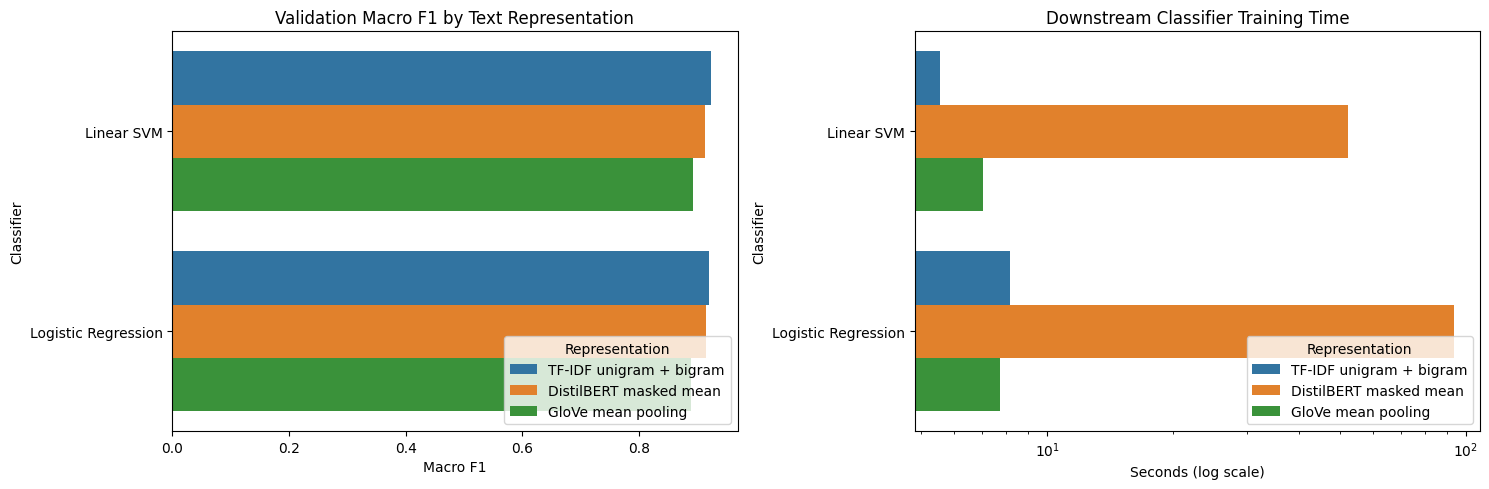

In [106]:
comparison_experiment_ids = [
    "logistic_regression__tfidf_unigram_bigram",
    "logistic_regression__glove_mean_100d",
    "logistic_regression__distilbert_mean_768d",
    "linear_svm__tfidf_unigram_bigram",
    "linear_svm__glove_mean_100d",
    "linear_svm__distilbert_mean_768d",
]
representation_names = {
    "tfidf_unigram_bigram": "TF-IDF unigram + bigram",
    "glove_mean_100d": "GloVe mean pooling",
    "distilbert_mean_768d": "DistilBERT masked mean",
}
representation_comparison = unified_validation_results.loc[
    unified_validation_results["Experiment"].isin(comparison_experiment_ids)
].copy()
representation_comparison["Representation"] = representation_comparison[
    "Feature set"
].map(representation_names)
representation_comparison = representation_comparison.sort_values(
    ["Model", "Macro F1"], ascending=[True, False]
)

display(
    representation_comparison[
        [
            "Model", "Representation", "Accuracy", "Macro F1",
            "Weighted F1", "Training time (s)",
            "Validation prediction time (s)",
        ]
    ].round({
        "Accuracy": 4,
        "Macro F1": 4,
        "Weighted F1": 4,
        "Training time (s)": 2,
        "Validation prediction time (s)": 4,
    })
)
representation_comparison.to_csv(
    METRIC_DIR / "pretrained_representation_classifier_comparison.csv",
    index=False,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=representation_comparison,
    x="Macro F1",
    y="Model",
    hue="Representation",
    ax=axes[0],
)
axes[0].set(
    title="Validation Macro F1 by Text Representation",
    xlabel="Macro F1",
    ylabel="Classifier",
)
axes[0].legend(title="Representation", loc="lower right")

sns.barplot(
    data=representation_comparison,
    x="Training time (s)",
    y="Model",
    hue="Representation",
    ax=axes[1],
)
axes[1].set(
    title="Downstream Classifier Training Time",
    xlabel="Seconds (log scale)",
    ylabel="Classifier",
)
axes[1].set_xscale("log")
axes[1].legend(title="Representation", loc="lower right")
plt.tight_layout()
pretrained_comparison_figure_path = (
    FIGURE_DIR / "pretrained_embedding_classifier_comparison.png"
)
plt.savefig(pretrained_comparison_figure_path, dpi=150, bbox_inches="tight")
plt.show()


## 7.5. Validation Interpretation

Frozen DistilBERT embeddings produced higher validation Macro F1 than mean-pooled GloVe for both classifiers. Logistic Regression with frozen DistilBERT reached 0.9157, while Linear SVM with GloVe reached 0.8921. Within GloVe, Linear SVM performed slightly better than Logistic Regression (0.8921 versus 0.8896); within frozen DistilBERT, Logistic Regression was slightly ahead of Linear SVM (0.9157 versus 0.9142).

The strongest result in this section remained below the Phase 7 TF-IDF unigram–bigram and Linear SVM baseline, which obtained 0.9230 validation Macro F1. In this experiment, using DistilBERT only as a fixed feature extractor therefore did not automatically outperform a strong sparse lexical representation. The reported fitting times cover downstream classifiers only; embedding extraction was measured separately, so the runtime values are descriptive rather than controlled end-to-end benchmarks.


# **8. BiLSTM Text Classification**
---
This section establishes the first end-to-end deep learning baseline. A vocabulary is learned exclusively from the training subset, and each minimally cleaned article is converted into a fixed-length sequence containing explicit padding and unknown-word tokens. A bidirectional LSTM then learns its word embeddings and classifier jointly.

Model development uses the established training and validation subsets. The official test set is not encoded, loaded, or evaluated during epoch selection.


## 8.1. Experimental Configuration

The maximum length of 128 tokens covers nearly all AG News articles while bounding memory use. The vocabulary and network sizes are capped to keep training practical on a standard Colab GPU. Early stopping monitors validation Macro F1 because it assigns equal importance to all four topics.


In [17]:
BILSTM_CONFIG = {
    "max_vocabulary_size": 50_000,
    "minimum_token_frequency": 2,
    "max_sequence_length": 128,
    "embedding_dimension": 128,
    "hidden_size": 128,
    "dropout": 0.30,
    "batch_size": 256,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 8,
    "early_stopping_patience": 2,
    "minimum_f1_improvement": 1e-4,
    "gradient_clip_norm": 1.0,
}

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_INDEX = 0
UNK_INDEX = 1
NUM_CLASSES = len(LABEL_MAP)

BILSTM_MODEL_DIR = MODEL_DIR / "bilstm"
BILSTM_MODEL_DIR.mkdir(parents=True, exist_ok=True)
BILSTM_CHECKPOINT_PATH = BILSTM_MODEL_DIR / "best_validation_model.pt"

display(pd.DataFrame([
    {"Parameter": name.replace("_", " ").title(), "Value": value}
    for name, value in BILSTM_CONFIG.items()
]))
print(f"Training device: {device}")
print(f"Checkpoint path: {BILSTM_CHECKPOINT_PATH.as_posix()}")


,Parameter,Value
0,Max Vocabulary Size,50000.0000
1,Minimum Token Frequency,2.0000
2,Max Sequence Length,128.0000
3,Embedding Dimension,128.0000
4,Hidden Size,128.0000
5,Dropout,0.3000
6,Batch Size,256.0000
7,Learning Rate,0.0010
8,Weight Decay,0.0001
9,Epochs,8.0000


Training device: cuda
Checkpoint path: models/bilstm/best_validation_model.pt


## 8.2. Training-only Vocabulary

Token frequencies are counted only in `train_split`. Tokens are ordered deterministically by decreasing frequency and then alphabetically, after which the configured frequency and size limits are applied. Validation-only words therefore map to `<unk>` rather than influencing the vocabulary.


In [18]:
BILSTM_TOKEN_PATTERN = re.compile(r"\b\w+(?:['’]\w+)*\b")

def tokenize_for_bilstm(text):
    """Return lowercase word tokens for the BiLSTM sequence model."""
    return BILSTM_TOKEN_PATTERN.findall(text.lower())

def build_training_vocabulary(texts, max_size, min_frequency):
    """Build a deterministic vocabulary from training texts only."""
    token_counts = Counter()
    for text in texts:
        token_counts.update(tokenize_for_bilstm(text))

    retained_tokens = [
        (token, frequency)
        for token, frequency in token_counts.items()
        if frequency >= min_frequency
    ]
    retained_tokens.sort(key=lambda item: (-item[1], item[0]))
    retained_tokens = retained_tokens[: max_size - 2]

    vocabulary = {PAD_TOKEN: PAD_INDEX, UNK_TOKEN: UNK_INDEX}
    vocabulary.update({
        token: index
        for index, (token, _) in enumerate(retained_tokens, start=2)
    })
    return vocabulary, token_counts

bilstm_vocabulary, bilstm_training_token_counts = build_training_vocabulary(
    train_split["text_minimal"],
    max_size=BILSTM_CONFIG["max_vocabulary_size"],
    min_frequency=BILSTM_CONFIG["minimum_token_frequency"],
)

assert bilstm_vocabulary[PAD_TOKEN] == PAD_INDEX
assert bilstm_vocabulary[UNK_TOKEN] == UNK_INDEX
assert len(bilstm_vocabulary) <= BILSTM_CONFIG["max_vocabulary_size"]

total_training_tokens = sum(bilstm_training_token_counts.values())
retained_training_tokens = sum(
    frequency
    for token, frequency in bilstm_training_token_counts.items()
    if token in bilstm_vocabulary
)
vocabulary_summary = pd.DataFrame([{
    "Vocabulary source": "Training subset only",
    "Distinct training tokens": len(bilstm_training_token_counts),
    "Retained vocabulary size": len(bilstm_vocabulary),
    "Training token coverage (%)": 100 * retained_training_tokens / total_training_tokens,
    "Padding index": PAD_INDEX,
    "Unknown index": UNK_INDEX,
}])
display(vocabulary_summary.round({"Training token coverage (%)": 2}))


,Vocabulary source,Distinct training tokens,Retained vocabulary size,Training token coverage (%),Padding index,Unknown index
0,Training subset only,65034,43481,99.48,0,1


## 8.3. Sequence Encoding and Data Loaders

Each article is truncated to the configured maximum length and padded on the right with `<pad>`. Empty inputs receive one `<unk>` token so that every sequence has a valid length. The training loader shuffles with a seeded generator; the validation loader preserves order.


In [19]:
def encode_bilstm_texts(texts, vocabulary, max_length):
    """Encode and right-pad a text collection without learning new tokens."""
    sequences = np.full(
        (len(texts), max_length), PAD_INDEX, dtype=np.int64
    )
    lengths = np.empty(len(texts), dtype=np.int64)
    was_truncated = np.zeros(len(texts), dtype=bool)

    for row_index, text in enumerate(texts):
        tokens = tokenize_for_bilstm(text)
        was_truncated[row_index] = len(tokens) > max_length
        token_ids = [
            vocabulary.get(token, UNK_INDEX)
            for token in tokens[:max_length]
        ]
        if not token_ids:
            token_ids = [UNK_INDEX]
        sequences[row_index, :len(token_ids)] = token_ids
        lengths[row_index] = len(token_ids)
    return sequences, lengths, was_truncated

class NewsSequenceDataset(Dataset):
    """Provide padded token sequences, true lengths, and class labels."""
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.from_numpy(sequences)
        self.lengths = torch.from_numpy(lengths)
        self.labels = torch.as_tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.sequences[index], self.lengths[index], self.labels[index]

train_sequences, train_sequence_lengths, train_was_truncated = encode_bilstm_texts(
    train_split["text_minimal"],
    bilstm_vocabulary,
    BILSTM_CONFIG["max_sequence_length"],
)
validation_sequences, validation_sequence_lengths, validation_was_truncated = encode_bilstm_texts(
    validation_split["text_minimal"],
    bilstm_vocabulary,
    BILSTM_CONFIG["max_sequence_length"],
)

train_sequence_dataset = NewsSequenceDataset(
    train_sequences,
    train_sequence_lengths,
    train_split["label"].to_numpy(dtype=np.int64),
)
validation_sequence_dataset = NewsSequenceDataset(
    validation_sequences,
    validation_sequence_lengths,
    validation_split["label"].to_numpy(dtype=np.int64),
)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)
loader_options = {
    "batch_size": BILSTM_CONFIG["batch_size"],
    "num_workers": 0,
    "pin_memory": device.type == "cuda",
}
train_sequence_loader = DataLoader(
    train_sequence_dataset,
    shuffle=True,
    generator=loader_generator,
    **loader_options,
)
validation_sequence_loader = DataLoader(
    validation_sequence_dataset,
    shuffle=False,
    **loader_options,
)

sequence_summary = pd.DataFrame([
    {
        "Split": "Train",
        "Samples": len(train_sequence_dataset),
        "Sequence shape": str(train_sequences.shape),
        "Mean retained length": train_sequence_lengths.mean(),
        "Truncated samples": int(train_was_truncated.sum()),
    },
    {
        "Split": "Validation",
        "Samples": len(validation_sequence_dataset),
        "Sequence shape": str(validation_sequences.shape),
        "Mean retained length": validation_sequence_lengths.mean(),
        "Truncated samples": int(validation_was_truncated.sum()),
    },
])
display(sequence_summary.round({"Mean retained length": 2}))
print("Official test records encoded in this section: 0")


,Split,Samples,Sequence shape,Mean retained length,Truncated samples
0,Train,107973,"(107973, 128)",38.34,57
1,Validation,11987,"(11987, 128)",38.18,7


Official test records encoded in this section: 0


## 8.4. BiLSTM Architecture

The embedding layer is learned jointly with the classifier and ignores the padding index. Packed sequences prevent padded positions from entering the recurrent computation. The final forward and backward hidden states are concatenated, regularized with dropout, and mapped to four unnormalized class logits.


In [20]:
class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM classifier for padded news sequences."""
    def __init__(
        self,
        vocabulary_size,
        embedding_dimension,
        hidden_size,
        dropout,
        num_classes,
        padding_index,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            vocabulary_size,
            embedding_dimension,
            padding_idx=padding_index,
        )
        self.embedding_dropout = nn.Dropout(dropout)
        self.bilstm = nn.LSTM(
            input_size=embedding_dimension,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
        )
        self.output_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(2 * hidden_size, num_classes)

    def forward(self, token_ids, lengths):
        embedded = self.embedding_dropout(self.embedding(token_ids))
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden_state, _) = self.bilstm(packed)
        document_state = torch.cat(
            (hidden_state[-2], hidden_state[-1]), dim=1
        )
        return self.classifier(self.output_dropout(document_state))

bilstm_model = BiLSTMClassifier(
    vocabulary_size=len(bilstm_vocabulary),
    embedding_dimension=BILSTM_CONFIG["embedding_dimension"],
    hidden_size=BILSTM_CONFIG["hidden_size"],
    dropout=BILSTM_CONFIG["dropout"],
    num_classes=NUM_CLASSES,
    padding_index=PAD_INDEX,
).to(device)

bilstm_parameter_count = sum(
    parameter.numel() for parameter in bilstm_model.parameters()
)
trainable_parameter_count = sum(
    parameter.numel()
    for parameter in bilstm_model.parameters()
    if parameter.requires_grad
)
display(pd.DataFrame([{
    "Model": "BiLSTM",
    "Vocabulary size": len(bilstm_vocabulary),
    "Total parameters": bilstm_parameter_count,
    "Trainable parameters": trainable_parameter_count,
    "Output classes": NUM_CLASSES,
}]))


,Model,Vocabulary size,Total parameters,Trainable parameters,Output classes
0,BiLSTM,43481,5830788,5830788,4


## 8.5. Training, Early Stopping, and Checkpointing

Cross-entropy loss and AdamW optimize all trainable parameters. Gradient clipping limits unstable recurrent updates. After every epoch, validation loss, Accuracy, and Macro F1 are measured without gradient tracking. A checkpoint is written only when validation Macro F1 improves; training stops after the configured number of non-improving epochs. The best checkpoint is restored before reporting the final validation result.


In [21]:
def run_bilstm_epoch(model, data_loader, criterion, optimizer=None):
    """Run one training or validation epoch and return measured statistics."""
    is_training = optimizer is not None
    model.train(mode=is_training)
    total_loss = 0.0
    total_samples = 0
    predictions = []
    targets = []

    for token_ids, lengths, labels in data_loader:
        token_ids = token_ids.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(token_ids, lengths)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                nn.utils.clip_grad_norm_(
                    model.parameters(), BILSTM_CONFIG["gradient_clip_norm"]
                )
                optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        if not is_training:
            predictions.extend(logits.argmax(dim=1).cpu().numpy())
            targets.extend(labels.cpu().numpy())

    statistics = {"Loss": total_loss / total_samples}
    if not is_training:
        statistics.update({
            "Accuracy": accuracy_score(targets, predictions),
            "Macro F1": f1_score(
                targets,
                predictions,
                labels=sorted(LABEL_MAP),
                average="macro",
                zero_division=0,
            ),
        })
    return statistics


In [22]:
bilstm_criterion = nn.CrossEntropyLoss()
bilstm_optimizer = torch.optim.AdamW(
    bilstm_model.parameters(),
    lr=BILSTM_CONFIG["learning_rate"],
    weight_decay=BILSTM_CONFIG["weight_decay"],
)

bilstm_history_rows = []
best_validation_macro_f1 = -np.inf
best_epoch = 0
epochs_without_improvement = 0
training_start_time = perf_counter()

for epoch in range(1, BILSTM_CONFIG["epochs"] + 1):
    epoch_start_time = perf_counter()
    training_statistics = run_bilstm_epoch(
        bilstm_model,
        train_sequence_loader,
        bilstm_criterion,
        optimizer=bilstm_optimizer,
    )
    with torch.no_grad():
        validation_statistics = run_bilstm_epoch(
            bilstm_model,
            validation_sequence_loader,
            bilstm_criterion,
        )

    epoch_time = perf_counter() - epoch_start_time
    bilstm_history_rows.append({
        "Epoch": epoch,
        "Training loss": training_statistics["Loss"],
        "Validation loss": validation_statistics["Loss"],
        "Validation Accuracy": validation_statistics["Accuracy"],
        "Validation Macro F1": validation_statistics["Macro F1"],
        "Epoch time (s)": epoch_time,
    })
    print(
        f"Epoch {epoch:02d} | "
        f"train loss {training_statistics['Loss']:.4f} | "
        f"validation loss {validation_statistics['Loss']:.4f} | "
        f"validation accuracy {validation_statistics['Accuracy']:.4f} | "
        f"validation Macro F1 {validation_statistics['Macro F1']:.4f} | "
        f"{epoch_time:.1f} s"
    )

    improved = (
        validation_statistics["Macro F1"]
        > best_validation_macro_f1
        + BILSTM_CONFIG["minimum_f1_improvement"]
    )
    if improved:
        best_validation_macro_f1 = validation_statistics["Macro F1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": {
                name: value.detach().cpu()
                for name, value in bilstm_model.state_dict().items()
            },
            "validation_metrics": validation_statistics,
            "config": BILSTM_CONFIG,
            "vocabulary": bilstm_vocabulary,
            "padding_token": PAD_TOKEN,
            "unknown_token": UNK_TOKEN,
        }, BILSTM_CHECKPOINT_PATH)
        print("  Saved new best validation checkpoint.")
    else:
        epochs_without_improvement += 1
        if (
            epochs_without_improvement
            >= BILSTM_CONFIG["early_stopping_patience"]
        ):
            print("Early stopping activated.")
            break

bilstm_training_time = perf_counter() - training_start_time
bilstm_history = pd.DataFrame(bilstm_history_rows)
bilstm_history.to_csv(
    METRIC_DIR / "bilstm_training_history.csv", index=False
)

best_checkpoint = torch.load(
    BILSTM_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)
bilstm_model.load_state_dict(best_checkpoint["model_state_dict"])
bilstm_model.to(device)
with torch.no_grad():
    restored_validation_statistics = run_bilstm_epoch(
        bilstm_model,
        validation_sequence_loader,
        bilstm_criterion,
    )

assert best_checkpoint["epoch"] == best_epoch
assert np.isclose(
    restored_validation_statistics["Macro F1"],
    best_checkpoint["validation_metrics"]["Macro F1"],
)

bilstm_validation_result = pd.DataFrame([{
    "Model": "BiLSTM",
    "Best epoch": best_epoch,
    "Validation loss": restored_validation_statistics["Loss"],
    "Validation Accuracy": restored_validation_statistics["Accuracy"],
    "Validation Macro F1": restored_validation_statistics["Macro F1"],
    "Training time (s)": bilstm_training_time,
    "Trainable parameters": trainable_parameter_count,
    "Checkpoint": BILSTM_CHECKPOINT_PATH.as_posix(),
}])
bilstm_validation_result.to_csv(
    METRIC_DIR / "bilstm_validation_results.csv", index=False
)

display(bilstm_history.round(4))
display(bilstm_validation_result.round({
    "Validation loss": 4,
    "Validation Accuracy": 4,
    "Validation Macro F1": 4,
    "Training time (s)": 2,
}))
print(f"Restored checkpoint from validation epoch {best_epoch}.")
print("Official test evaluations performed: 0")


Epoch 01 | train loss 0.6752 | validation loss 0.4888 | validation accuracy 0.8591 | validation Macro F1 0.8586 | 20.0 s
  Saved new best validation checkpoint.


Epoch 02 | train loss 0.3533 | validation loss 0.3645 | validation accuracy 0.8837 | validation Macro F1 0.8842 | 19.1 s
  Saved new best validation checkpoint.


Epoch 03 | train loss 0.2957 | validation loss 0.3296 | validation accuracy 0.8994 | validation Macro F1 0.8990 | 18.7 s
  Saved new best validation checkpoint.


Epoch 04 | train loss 0.2588 | validation loss 0.3308 | validation accuracy 0.8991 | validation Macro F1 0.8990 | 17.7 s


Epoch 05 | train loss 0.2319 | validation loss 0.3439 | validation accuracy 0.9024 | validation Macro F1 0.9025 | 15.8 s
  Saved new best validation checkpoint.


...

Epoch 07 | train loss 0.1943 | validation loss 0.3201 | validation accuracy 0.9082 | validation Macro F1 0.9080 | 17.5 s
  Saved new best validation checkpoint.


Epoch 08 | train loss 0.1764 | validation loss 0.3275 | validation accuracy 0.9071 | validation Macro F1 0.9072 | 18.1 s


,Epoch,Training loss,Validation loss,Validation Accuracy,Validation Macro F1,Epoch time (s)
0,1,0.6752,0.4888,0.8591,0.8586,20.0425
1,2,0.3533,0.3645,0.8837,0.8842,19.1482
2,3,0.2957,0.3296,0.8994,0.8990,18.7298
3,4,0.2588,0.3308,0.8991,0.8990,17.6751
4,5,0.2319,0.3439,0.9024,0.9025,15.8330
5,6,0.2090,0.3193,0.9058,0.9058,8.5079
6,7,0.1943,0.3201,0.9082,0.9080,17.5072
7,8,0.1764,0.3275,0.9071,0.9072,18.1302


,Model,Best epoch,Validation loss,Validation Accuracy,Validation Macro F1,Training time (s),Trainable parameters,Checkpoint
0,BiLSTM,7,0.3201,0.9082,0.908,136.1,5830788,models/bilstm/best_validation_model.pt


Restored checkpoint from validation epoch 7.
Official test evaluations performed: 0


## 8.6. Learning Curves

The curves below present optimization progress and validation performance by epoch. Their interpretation is deferred until the recorded outputs have been inspected.


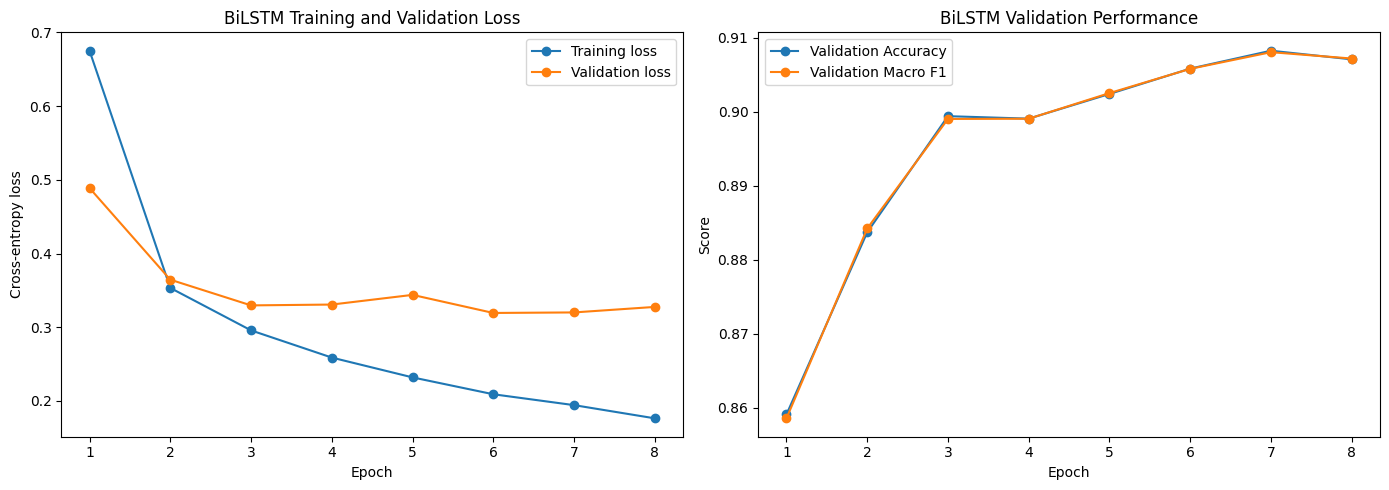

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    bilstm_history["Epoch"],
    bilstm_history["Training loss"],
    marker="o",
    label="Training loss",
)
axes[0].plot(
    bilstm_history["Epoch"],
    bilstm_history["Validation loss"],
    marker="o",
    label="Validation loss",
)
axes[0].set(
    title="BiLSTM Training and Validation Loss",
    xlabel="Epoch",
    ylabel="Cross-entropy loss",
)
axes[0].set_xticks(bilstm_history["Epoch"])
axes[0].legend()

axes[1].plot(
    bilstm_history["Epoch"],
    bilstm_history["Validation Accuracy"],
    marker="o",
    label="Validation Accuracy",
)
axes[1].plot(
    bilstm_history["Epoch"],
    bilstm_history["Validation Macro F1"],
    marker="o",
    label="Validation Macro F1",
)
axes[1].set(
    title="BiLSTM Validation Performance",
    xlabel="Epoch",
    ylabel="Score",
)
axes[1].set_xticks(bilstm_history["Epoch"])
axes[1].legend()

plt.tight_layout()
bilstm_curve_path = FIGURE_DIR / "bilstm_learning_curves.png"
plt.savefig(bilstm_curve_path, dpi=150, bbox_inches="tight")
plt.show()


## 8.7. BiLSTM Observations

Training loss decreased from 0.6752 to 0.1764 across eight epochs. Validation loss improved rapidly through epoch 3 and reached its lowest recorded value at epoch 6 (0.3193), but it did not continue to decrease consistently while training loss kept falling. Validation Macro F1 nevertheless increased from 0.8586 to a peak of 0.9080 at epoch 7, before declining slightly to 0.9072 at epoch 8. This pattern indicates mild late-stage overfitting rather than severe training instability.

The checkpoint from epoch 7 was selected and restored according to the predefined validation Macro F1 criterion. Early-stopping patience was configured, but it was not reached: training completed the maximum eight epochs with only one non-improving epoch after the final improvement.


# **9. Fine-tuning DistilBERT**
---
This section fine-tunes `distilbert-base-uncased` end to end for the four AG News labels. The established training subset supplies optimization examples, while validation data is used only for epoch-level evaluation and best-checkpoint selection. The official test set remains untouched.


## 9.1. Fine-tuning Configuration

Dynamic padding limits each batch to its longest sequence, subject to the configured maximum of 128 tokens. Mixed precision is enabled only on CUDA to reduce GPU memory and training time. The defaults target a standard Colab GPU and remain explicit so the experiment can be reproduced.


In [17]:
DISTILBERT_FINETUNE_CONFIG = {
    "model_name": "distilbert-base-uncased",
    "learning_rate": 2e-5,
    "batch_size": 16,  # Reduce this first if the selected Colab GPU runs out of memory.
    "evaluation_batch_size": 32,
    "epochs": 2,
    "max_sequence_length": 128,  # Reduce only as an explicit change to retained context.
    "weight_decay": 0.01,
    "gradient_clip_norm": 1.0,
    "use_mixed_precision": True,
}

DISTILBERT_FINETUNE_DIR = MODEL_DIR / "distilbert_finetuned" / "best_validation_model"
DISTILBERT_FINETUNE_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

display(pd.DataFrame([{
    "Parameter": key.replace("_", " ").title(), "Value": value
} for key, value in DISTILBERT_FINETUNE_CONFIG.items()]))
print(f"Fine-tuning device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")


,Parameter,Value
0,Model Name,distilbert-base-uncased
1,Learning Rate,0.00002
2,Batch Size,16
3,Evaluation Batch Size,32
4,Epochs,2
5,Max Sequence Length,128
6,Weight Decay,0.01
7,Gradient Clip Norm,1.0
8,Use Mixed Precision,True


Fine-tuning device: cuda
CUDA available: True


## 9.2. Tokenization and Data Loaders

The tokenizer receives minimally cleaned text and performs truncation plus dynamic batch padding. Dataset objects store raw text and labels only; tokenization does not learn from validation data. A seeded generator controls training-batch shuffling.


In [18]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message=".*cache-system uses symlinks.*"
    )
    distilbert_finetune_tokenizer = AutoTokenizer.from_pretrained(
        DISTILBERT_FINETUNE_CONFIG["model_name"]
    )

class TransformerClassificationDataset(Dataset):
    """Store text-label pairs without precomputing padded tensors."""
    def __init__(self, texts, labels):
        self.texts = texts.reset_index(drop=True)
        self.labels = np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.texts.iloc[index], int(self.labels[index])

def collate_distilbert_batch(batch):
    """Tokenize one batch with truncation and dynamic padding."""
    texts, labels = zip(*batch)
    encoded = distilbert_finetune_tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=DISTILBERT_FINETUNE_CONFIG["max_sequence_length"],
        return_tensors="pt",
    )
    encoded["labels"] = torch.tensor(labels, dtype=torch.long)
    return encoded

distilbert_train_dataset = TransformerClassificationDataset(
    train_split["text_minimal"], train_split["label"]
)
distilbert_validation_dataset = TransformerClassificationDataset(
    validation_split["text_minimal"], validation_split["label"]
)
distilbert_loader_generator = torch.Generator().manual_seed(SEED)
distilbert_train_loader = DataLoader(
    distilbert_train_dataset,
    batch_size=DISTILBERT_FINETUNE_CONFIG["batch_size"],
    shuffle=True,
    generator=distilbert_loader_generator,
    collate_fn=collate_distilbert_batch,
    num_workers=0,
    pin_memory=device.type == "cuda",
)
distilbert_validation_loader = DataLoader(
    distilbert_validation_dataset,
    batch_size=DISTILBERT_FINETUNE_CONFIG["evaluation_batch_size"],
    shuffle=False,
    collate_fn=collate_distilbert_batch,
    num_workers=0,
    pin_memory=device.type == "cuda",
)
display(pd.DataFrame([
    {"Split":"Train", "Samples":len(distilbert_train_dataset), "Shuffled":True},
    {"Split":"Validation", "Samples":len(distilbert_validation_dataset), "Shuffled":False},
]))
print("Official test records tokenized in this section: 0")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

,Split,Samples,Shuffled
0,Train,107973,True
1,Validation,11987,False


Official test records tokenized in this section: 0


## 9.3. Sequence-classification Model

`AutoModelForSequenceClassification` adds a four-class classification head to DistilBERT. Explicit label mappings are stored with the checkpoint, making predicted class indices interpretable when the model is reloaded.


In [19]:
distilbert_id_to_label = {index: name for index, name in LABEL_MAP.items()}
distilbert_label_to_id = {name: index for index, name in LABEL_MAP.items()}
distilbert_classifier = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_FINETUNE_CONFIG["model_name"],
    num_labels=len(LABEL_MAP),
    id2label=distilbert_id_to_label,
    label2id=distilbert_label_to_id,
).to(device)

distilbert_trainable_parameters = sum(
    parameter.numel() for parameter in distilbert_classifier.parameters()
    if parameter.requires_grad
)
display(pd.DataFrame([{
    "Model": DISTILBERT_FINETUNE_CONFIG["model_name"],
    "Trainable parameters": distilbert_trainable_parameters,
    "Output classes": distilbert_classifier.config.num_labels,
}]))


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,Model,Trainable parameters,Output classes
0,distilbert-base-uncased,66956548,4


## 9.4. Fine-tuning and Best-model Selection

AdamW updates all model parameters. Each epoch records training loss and evaluates validation loss, Accuracy, and Macro F1. A Hugging Face checkpoint is saved only when validation Macro F1 improves, then reloaded for a final validation consistency check. No test-set result enters this selection process.


In [20]:
def run_distilbert_epoch(model, data_loader, optimizer=None, scaler=None):
    """Run one fine-tuning or validation epoch."""
    is_training = optimizer is not None
    model.train(mode=is_training)
    total_loss = 0.0
    total_samples = 0
    predictions, targets = [], []
    use_amp = (
        device.type == "cuda"
        and DISTILBERT_FINETUNE_CONFIG["use_mixed_precision"]
    )

    for batch in data_loader:
        batch = {key: value.to(device, non_blocking=True) for key, value in batch.items()}
        if is_training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(is_training):
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                outputs = model(**batch)
                loss = outputs.loss
            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(
                    model.parameters(), DISTILBERT_FINETUNE_CONFIG["gradient_clip_norm"]
                )
                scaler.step(optimizer)
                scaler.update()

        batch_size = batch["labels"].size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        if not is_training:
            predictions.extend(outputs.logits.argmax(dim=1).cpu().numpy())
            targets.extend(batch["labels"].cpu().numpy())

    statistics = {"Loss": total_loss / total_samples}
    if not is_training:
        statistics.update({
            "Accuracy": accuracy_score(targets, predictions),
            "Macro F1": f1_score(
                targets, predictions, labels=sorted(LABEL_MAP),
                average="macro", zero_division=0,
            ),
        })
    return statistics


In [21]:
distilbert_optimizer = torch.optim.AdamW(
    distilbert_classifier.parameters(),
    lr=DISTILBERT_FINETUNE_CONFIG["learning_rate"],
    weight_decay=DISTILBERT_FINETUNE_CONFIG["weight_decay"],
)
distilbert_amp_enabled = (
    device.type == "cuda" and DISTILBERT_FINETUNE_CONFIG["use_mixed_precision"]
)
distilbert_scaler = torch.amp.GradScaler("cuda", enabled=distilbert_amp_enabled)

distilbert_history_rows = []
best_distilbert_macro_f1 = -np.inf
best_distilbert_epoch = 0
distilbert_training_start = perf_counter()

for epoch in range(1, DISTILBERT_FINETUNE_CONFIG["epochs"] + 1):
    epoch_start = perf_counter()
    train_statistics = run_distilbert_epoch(
        distilbert_classifier, distilbert_train_loader,
        optimizer=distilbert_optimizer, scaler=distilbert_scaler,
    )
    with torch.no_grad():
        validation_statistics = run_distilbert_epoch(
            distilbert_classifier, distilbert_validation_loader
        )
    epoch_time = perf_counter() - epoch_start
    distilbert_history_rows.append({
        "Epoch":epoch, "Training loss":train_statistics["Loss"],
        "Validation loss":validation_statistics["Loss"],
        "Validation Accuracy":validation_statistics["Accuracy"],
        "Validation Macro F1":validation_statistics["Macro F1"],
        "Epoch time (s)":epoch_time,
    })
    print(
        f"Epoch {epoch:02d} | train loss {train_statistics['Loss']:.4f} | "
        f"validation loss {validation_statistics['Loss']:.4f} | "
        f"validation accuracy {validation_statistics['Accuracy']:.4f} | "
        f"validation Macro F1 {validation_statistics['Macro F1']:.4f} | "
        f"{epoch_time:.1f} s"
    )
    if validation_statistics["Macro F1"] > best_distilbert_macro_f1:
        best_distilbert_macro_f1 = validation_statistics["Macro F1"]
        best_distilbert_epoch = epoch
        distilbert_classifier.save_pretrained(
            DISTILBERT_FINETUNE_DIR, safe_serialization=True
        )
        distilbert_finetune_tokenizer.save_pretrained(DISTILBERT_FINETUNE_DIR)
        print("  Saved new best validation checkpoint.")

distilbert_finetune_time = perf_counter() - distilbert_training_start
distilbert_finetune_history = pd.DataFrame(distilbert_history_rows)
distilbert_finetune_history.to_csv(
    METRIC_DIR / "distilbert_finetuning_history.csv", index=False
)

del distilbert_classifier
if torch.cuda.is_available():
    torch.cuda.empty_cache()
distilbert_classifier = AutoModelForSequenceClassification.from_pretrained(
    DISTILBERT_FINETUNE_DIR
).to(device)
with torch.no_grad():
    restored_distilbert_statistics = run_distilbert_epoch(
        distilbert_classifier, distilbert_validation_loader
    )

distilbert_validation_result = pd.DataFrame([{
    "Model":"Fine-tuned DistilBERT", "Best epoch":best_distilbert_epoch,
    "Validation loss":restored_distilbert_statistics["Loss"],
    "Validation Accuracy":restored_distilbert_statistics["Accuracy"],
    "Validation Macro F1":restored_distilbert_statistics["Macro F1"],
    "Training time (s)":distilbert_finetune_time,
    "Trainable parameters":distilbert_trainable_parameters,
    "Checkpoint":DISTILBERT_FINETUNE_DIR.as_posix(),
}])
distilbert_validation_result.to_csv(
    METRIC_DIR / "distilbert_finetuning_validation_results.csv", index=False
)
display(distilbert_finetune_history.round(4))
display(distilbert_validation_result.round(4))
print(f"Restored checkpoint from validation epoch {best_distilbert_epoch}.")
print("Official test evaluations performed: 0")


Epoch 01 | train loss 0.2374 | validation loss 0.1846 | validation accuracy 0.9435 | validation Macro F1 0.9434 | 424.0 s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved new best validation checkpoint.


Epoch 02 | train loss 0.1532 | validation loss 0.1889 | validation accuracy 0.9468 | validation Macro F1 0.9469 | 371.2 s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved new best validation checkpoint.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,Epoch,Training loss,Validation loss,Validation Accuracy,Validation Macro F1,Epoch time (s)
0,1,0.2374,0.1846,0.9435,0.9434,424.0227
1,2,0.1532,0.1889,0.9468,0.9469,371.1839


,Model,Best epoch,Validation loss,Validation Accuracy,Validation Macro F1,Training time (s),Trainable parameters,Checkpoint
0,Fine-tuned DistilBERT,2,0.1889,0.9468,0.9469,796.0745,66956548,models/distilbert_finetuned/best_validation_model


Restored checkpoint from validation epoch 2.
Official test evaluations performed: 0


## 9.5. Fine-tuning Interpretation

Validation Macro F1 increased from 0.9434 at epoch 1 to 0.9469 at epoch 2, although validation loss rose slightly from 0.1846 to 0.1889. The epoch 2 checkpoint was selected under the predefined Macro F1 criterion; this choice does not imply that it is preferable under every possible objective. If a Colab GPU cannot accommodate the configured batch, `batch_size` should be reduced explicitly and the change recorded.


# **10. Final Model Evaluation and Comparison**
---
This section performs the first and only final evaluation on the official AG News test split. One model is selected from each representation family using validation evidence established earlier: Linear SVM with unigram–bigram TF-IDF, Linear SVM with GloVe, Logistic Regression with frozen DistilBERT embeddings, BiLSTM, and fine-tuned DistilBERT. Test results are used for reporting rather than further tuning.


## 10.1. Final Evaluation Protocol

The stored fitted models and restored best neural checkpoints are reused without parameter changes. All model selection and hyperparameter decisions were completed with validation data; the official test set was evaluated only in this final stage, and later descriptive error analysis must not be used to retune the models.

Classifier-only inference time is reported for precomputed sparse or dense features, whereas neural timing includes batching, tokenization where applicable, and forward passes. Recorded fitting and training times also cover different stages across model families and may come from different execution sessions. They are therefore descriptive measurements rather than controlled end-to-end benchmarks.


In [36]:
def calculate_final_metrics(targets, predictions):
    """Calculate the common final classification metrics."""
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        targets, predictions, labels=list(LABEL_MAP), average="macro", zero_division=0
    )
    return {
        "Accuracy": accuracy_score(targets, predictions),
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": macro_f1,
        "Weighted F1": f1_score(
            targets, predictions, labels=list(LABEL_MAP),
            average="weighted", zero_division=0,
        ),
    }

def predict_bilstm(model, data_loader):
    model.eval(); predictions=[]
    start=perf_counter()
    with torch.no_grad():
        for token_ids, lengths, _ in data_loader:
            logits=model(token_ids.to(device), lengths.to(device))
            predictions.extend(logits.argmax(1).cpu().numpy())
    return np.asarray(predictions), perf_counter()-start

def predict_transformer(model, data_loader):
    model.eval(); predictions=[]
    use_amp=device.type=="cuda" and DISTILBERT_FINETUNE_CONFIG["use_mixed_precision"]
    start=perf_counter()
    with torch.no_grad():
        for batch in data_loader:
            labels=batch.pop("labels")
            batch={key:value.to(device,non_blocking=True) for key,value in batch.items()}
            with torch.autocast(device_type=device.type,dtype=torch.float16,enabled=use_amp):
                logits=model(**batch).logits
            predictions.extend(logits.argmax(1).cpu().numpy())
    return np.asarray(predictions), perf_counter()-start


In [37]:
validation_sources = {
    "traditional": pd.read_csv(METRIC_DIR / "traditional_ml_validation_results.csv"),
    "pretrained": pd.read_csv(METRIC_DIR / "pretrained_embedding_classifier_validation.csv"),
    "bilstm": pd.read_csv(METRIC_DIR / "bilstm_validation_results.csv"),
    "finetuned": pd.read_csv(METRIC_DIR / "distilbert_finetuning_validation_results.csv"),
}
selected_metadata = {
    "Linear SVM + TF-IDF": {
        "Selection ID": "linear_svm__tfidf_unigram_bigram",
        "Representation type": "Sparse TF-IDF unigram + bigram",
        "Timing scope": "Classifier fitting only",
        "Checkpoint/configuration": "C=1.0; TF-IDF (1,2); 100,000-feature cap",
        "source": "traditional",
    },
    "Linear SVM + GloVe": {
        "Selection ID": "linear_svm__glove_mean_100d",
        "Representation type": "GloVe mean embedding",
        "Timing scope": "Classifier fitting only",
        "Checkpoint/configuration": "C=1.0; glove-wiki-gigaword-100 mean pooling",
        "source": "pretrained",
    },
    "Logistic Regression + frozen DistilBERT": {
        "Selection ID": "logistic_regression__distilbert_mean_768d",
        "Representation type": "Frozen contextual embedding",
        "Timing scope": "Classifier fitting only",
        "Checkpoint/configuration": "C=1.0; distilbert-base-uncased masked mean",
        "source": "pretrained",
    },
    "BiLSTM": {
        "Selection ID": "bilstm_best_epoch_7",
        "Representation type": "Learned word embeddings + BiLSTM",
        "Timing scope": "End-to-end model training",
        "Checkpoint/configuration": bilstm_validation_result["Checkpoint"].iat[0],
        "source": "bilstm",
    },
    "Fine-tuned DistilBERT": {
        "Selection ID": "distilbert_finetuned_best_epoch_2",
        "Representation type": "End-to-end contextual Transformer",
        "Timing scope": "Transformer fine-tuning",
        "Checkpoint/configuration": distilbert_validation_result["Checkpoint"].iat[0],
        "source": "finetuned",
    },
}
for name, metadata in selected_metadata.items():
    table = validation_sources[metadata["source"]]
    if "Experiment" in table.columns:
        row = table.loc[table["Experiment"] == metadata["Selection ID"]].iloc[0]
    else:
        row = table.iloc[0]
    metadata["Selected validation Macro F1"] = row["Macro F1"] if "Macro F1" in row else row["Validation Macro F1"]
    metadata["Recorded model fitting/training time (s)"] = row["Training time (s)"]

assert selected_metadata["Linear SVM + TF-IDF"]["Selection ID"] == validation_sources["traditional"].iloc[0]["Experiment"]
assert selected_metadata["Linear SVM + GloVe"]["Selected validation Macro F1"] == validation_sources["pretrained"].query("`Feature set` == 'glove_mean_100d'")["Macro F1"].max()
assert selected_metadata["Logistic Regression + frozen DistilBERT"]["Selected validation Macro F1"] == validation_sources["pretrained"].query("`Feature set` == 'distilbert_mean_768d'")["Macro F1"].max()
assert int(validation_sources["bilstm"].iloc[0]["Best epoch"]) == 7
assert int(validation_sources["finetuned"].iloc[0]["Best epoch"]) == 2

y_test = test_split["label"].to_numpy(dtype=np.int64)
final_prediction_sets = {}
final_rows = []
def record_final_result(name, predictions, inference_time, inference_scope):
    assert len(predictions) == len(y_test)
    metadata = selected_metadata[name]
    final_prediction_sets[name] = predictions
    final_rows.append({
        "Model": name, "Selection ID": metadata["Selection ID"],
        "Representation type": metadata["Representation type"],
        "Selected validation Macro F1": metadata["Selected validation Macro F1"],
        **calculate_final_metrics(y_test, predictions),
        "Recorded model fitting/training time (s)": metadata["Recorded model fitting/training time (s)"],
        "Timing scope": metadata["Timing scope"],
        "Test inference time (s)": inference_time,
        "Inference scope": inference_scope,
        "Checkpoint/configuration": metadata["Checkpoint/configuration"],
    })

sparse_id="linear_svm__tfidf_unigram_bigram"
start=perf_counter(); sparse_predictions=fitted_traditional_models[sparse_id].predict(feature_sets["tfidf_unigram_bigram"]["matrices"]["test"])
record_final_result("Linear SVM + TF-IDF",sparse_predictions,perf_counter()-start,"Classifier prediction on precomputed features")
glove_test=np.load(PRETRAINED_FEATURE_DIR / f"{GLOVE_MODEL_NAME.replace('-', '_')}_test.npy",mmap_mode="r")
bert_test=np.load(PRETRAINED_FEATURE_DIR / f"{DISTILBERT_MODEL_NAME.replace('-', '_')}_mean_test.npy",mmap_mode="r")
for experiment_id,name,matrix in [("linear_svm__glove_mean_100d","Linear SVM + GloVe",glove_test),("logistic_regression__distilbert_mean_768d","Logistic Regression + frozen DistilBERT",bert_test)]:
    start=perf_counter(); predictions=fitted_pretrained_classifiers[experiment_id].predict(matrix)
    record_final_result(name,predictions,perf_counter()-start,"Classifier prediction on precomputed embeddings")
test_sequences,test_lengths,_=encode_bilstm_texts(test_split["text_minimal"],bilstm_vocabulary,BILSTM_CONFIG["max_sequence_length"])
test_sequence_loader=DataLoader(NewsSequenceDataset(test_sequences,test_lengths,y_test),batch_size=BILSTM_CONFIG["batch_size"],shuffle=False,num_workers=0,pin_memory=device.type=="cuda")
predictions,inference_time=predict_bilstm(bilstm_model,test_sequence_loader)
record_final_result("BiLSTM",predictions,inference_time,"Padded batches and neural forward passes")
distilbert_test_dataset=TransformerClassificationDataset(test_split["text_minimal"],y_test)
distilbert_test_loader=DataLoader(distilbert_test_dataset,batch_size=DISTILBERT_FINETUNE_CONFIG["evaluation_batch_size"],shuffle=False,collate_fn=collate_distilbert_batch,num_workers=0,pin_memory=device.type=="cuda")
predictions,inference_time=predict_transformer(distilbert_classifier,distilbert_test_loader)
record_final_result("Fine-tuned DistilBERT",predictions,inference_time,"Dynamic tokenization and neural forward passes")
assert set(final_prediction_sets) == set(selected_metadata)
final_test_results=pd.DataFrame(final_rows).sort_values("Macro F1",ascending=False).reset_index(drop=True)
final_test_results.insert(0,"Rank",np.arange(1,len(final_test_results)+1))
display(final_test_results.round(4))
final_test_results.to_csv(METRIC_DIR / "final_model_test_comparison.csv",index=False)
print("Final test evaluation stages completed: 1")
print(f"Selected models evaluated on the official test set: {len(final_test_results)}")


Rank,Model,Selection ID,Representation type,Selected validation Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Recorded model fitting/training time (s),Timing scope,Test inference time (s),Inference scope,Checkpoint/configuration
1,Fine-tuned DistilBERT,distilbert_finetuned_best_epoch_2,End-to-end contextual Transformer,0.9469,0.9442,0.9445,0.9442,0.9443,0.9443,796.0745,Transformer fine-tuning,5.4704,Dynamic tokenization and neural forward passes,models/distilbert_finetuned/best_validation_model
2,Linear SVM + TF-IDF,linear_svm__tfidf_unigram_bigram,Sparse TF-IDF unigram + bigram,0.9230,0.9214,0.9214,0.9214,0.9213,0.9213,5.5648,Classifier fitting only,0.0111,Classifier prediction on precomputed features,"C=1.0; TF-IDF (1,2); 100,000-feature cap"
3,Logistic Regression + frozen DistilBERT,logistic_regression__distilbert_mean_768d,Frozen contextual embedding,0.9157,0.9096,0.9096,0.9096,0.9095,0.9095,93.8774,Classifier fitting only,0.1274,Classifier prediction on precomputed embeddings,C=1.0; distilbert-base-uncased masked mean
4,BiLSTM,bilstm_best_epoch_7,Learned word embeddings + BiLSTM,0.9080,0.9087,0.9095,0.9087,0.9086,0.9086,136.1032,End-to-end model training,1.2042,Padded batches and neural forward passes,models/bilstm/best_validation_model.pt
5,Linear SVM + GloVe,linear_svm__glove_mean_100d,GloVe mean embedding,0.8921,0.8870,0.8866,0.8870,0.8867,0.8867,7.0258,Classifier fitting only,0.0173,Classifier prediction on precomputed embeddings,C=1.0; glove-wiki-gigaword-100 mean pooling


Final test evaluation stages completed: 1
Selected models evaluated on the official test set: 5


## 10.2. Performance Comparison and Error Patterns

The chart compares the common test metrics. Confusion matrices are shown for the strongest sparse baseline and both end-to-end neural models to expose class-specific errors across substantially different modeling approaches.


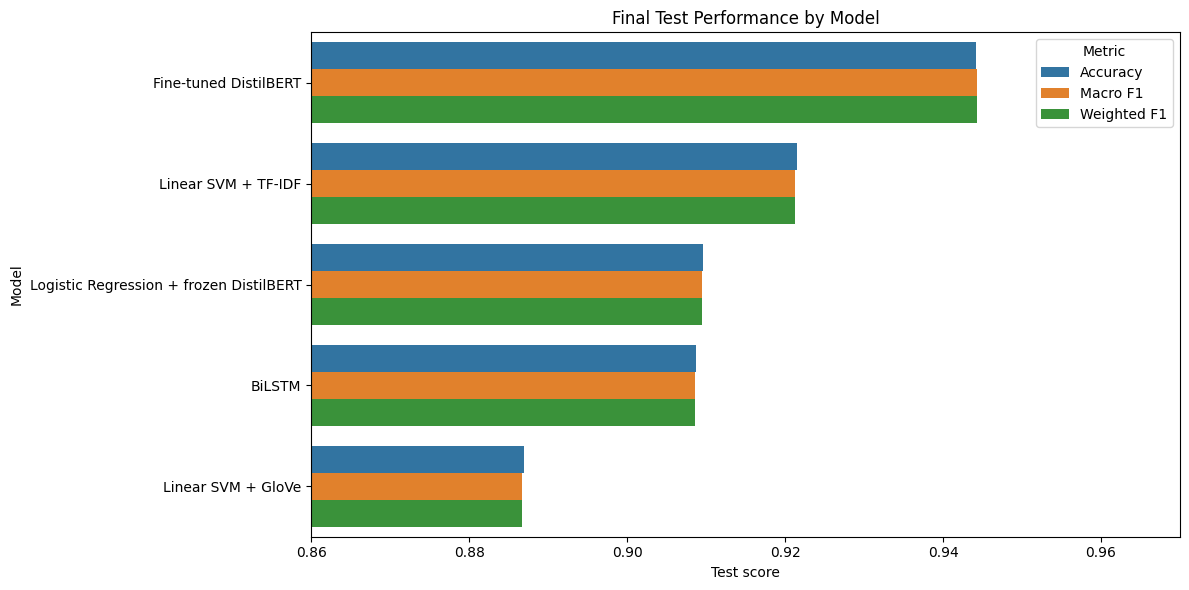

In [38]:
plot_data=final_test_results.melt(
    id_vars="Model",value_vars=["Accuracy","Macro F1","Weighted F1"],
    var_name="Metric",value_name="Score",
)
plt.figure(figsize=(12,6))
sns.barplot(data=plot_data,x="Score",y="Model",hue="Metric")
plt.title("Final Test Performance by Model")
plt.xlabel("Test score"); plt.ylabel("Model"); plt.xlim(0.86,0.97)
plt.tight_layout(); plt.savefig(FIGURE_DIR / "final_model_test_comparison.png",dpi=150,bbox_inches="tight"); plt.show()


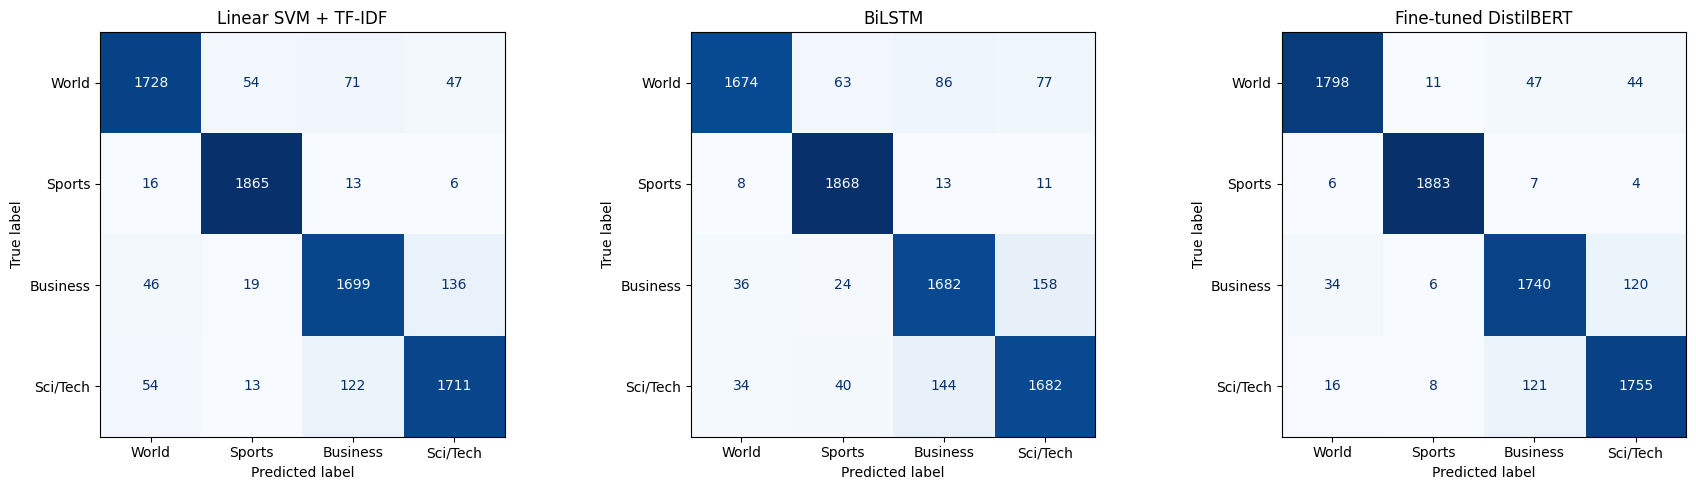

In [39]:
confusion_models=["Linear SVM + TF-IDF","BiLSTM","Fine-tuned DistilBERT"]
fig,axes=plt.subplots(1,3,figsize=(18,5))
for axis,name in zip(axes,confusion_models):
    ConfusionMatrixDisplay.from_predictions(
        y_test,final_prediction_sets[name],labels=list(LABEL_MAP),
        display_labels=list(LABEL_MAP.values()),cmap="Blues",colorbar=False,ax=axis,
    )
    axis.set_title(name)
plt.tight_layout(); plt.savefig(FIGURE_DIR / "final_representative_confusion_matrices.png",dpi=150,bbox_inches="tight"); plt.show()


## Comparative Analysis

Fine-tuned DistilBERT obtained the highest observed test Macro F1 at 0.9443. The TF-IDF unigram–bigram and Linear SVM baseline reached 0.9213, remaining competitive despite its simpler sparse representation. Frozen DistilBERT with Logistic Regression reached 0.9095, while fine-tuning the same Transformer family produced a higher observed result than using its embeddings as fixed features.

BiLSTM achieved 0.9086 test Macro F1, close to the frozen DistilBERT classifier, and Linear SVM with mean-pooled GloVe produced 0.8867. These values summarize predictive performance only; they do not establish universal superiority or statistical significance. Computational cost, representation complexity, and class-specific weaknesses require separate discussion, with the latter deferred to descriptive error analysis.


The aggregate metrics describe overall predictive performance, but they do not explain which topics are most frequently confused or which examples distinguish the models. The next section therefore examines class-level errors and disagreement patterns among representative models.
